# Stacked Bar Plots Continues Bayesian Model

## Stacked bar plots with svg

DIRECTIONAL BMI SLOPE PLOTS (CONTINUOUS MODEL)

COMPARTMENT: Non-Immune (nonimmune)
  ✅ Loading: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune/bayesian_results_continuous_with_rope.csv
  Rows loaded: 249
  ✅ Filtered to 245 rows. Cells: ['Acinar', 'Adipocytes', 'Endothelial', 'Fibroblasts', 'Islet endocrine', 'Neural', 'Normal ductal', 'Pericytes SMC', 'Schwann', 'Stellate', 'Tumor classical', 'Tumor epithelial', 'apCAF', 'iCAF']

  Creating directional BMI slope plot...
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune/continuous_publication_figures/stacked_bar_plots/bmi_slope_directional_nonimmune.png
  ✅ Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/stacked_bar_plots/nonimmune/bmi_slope_directional_nonimmune.svg


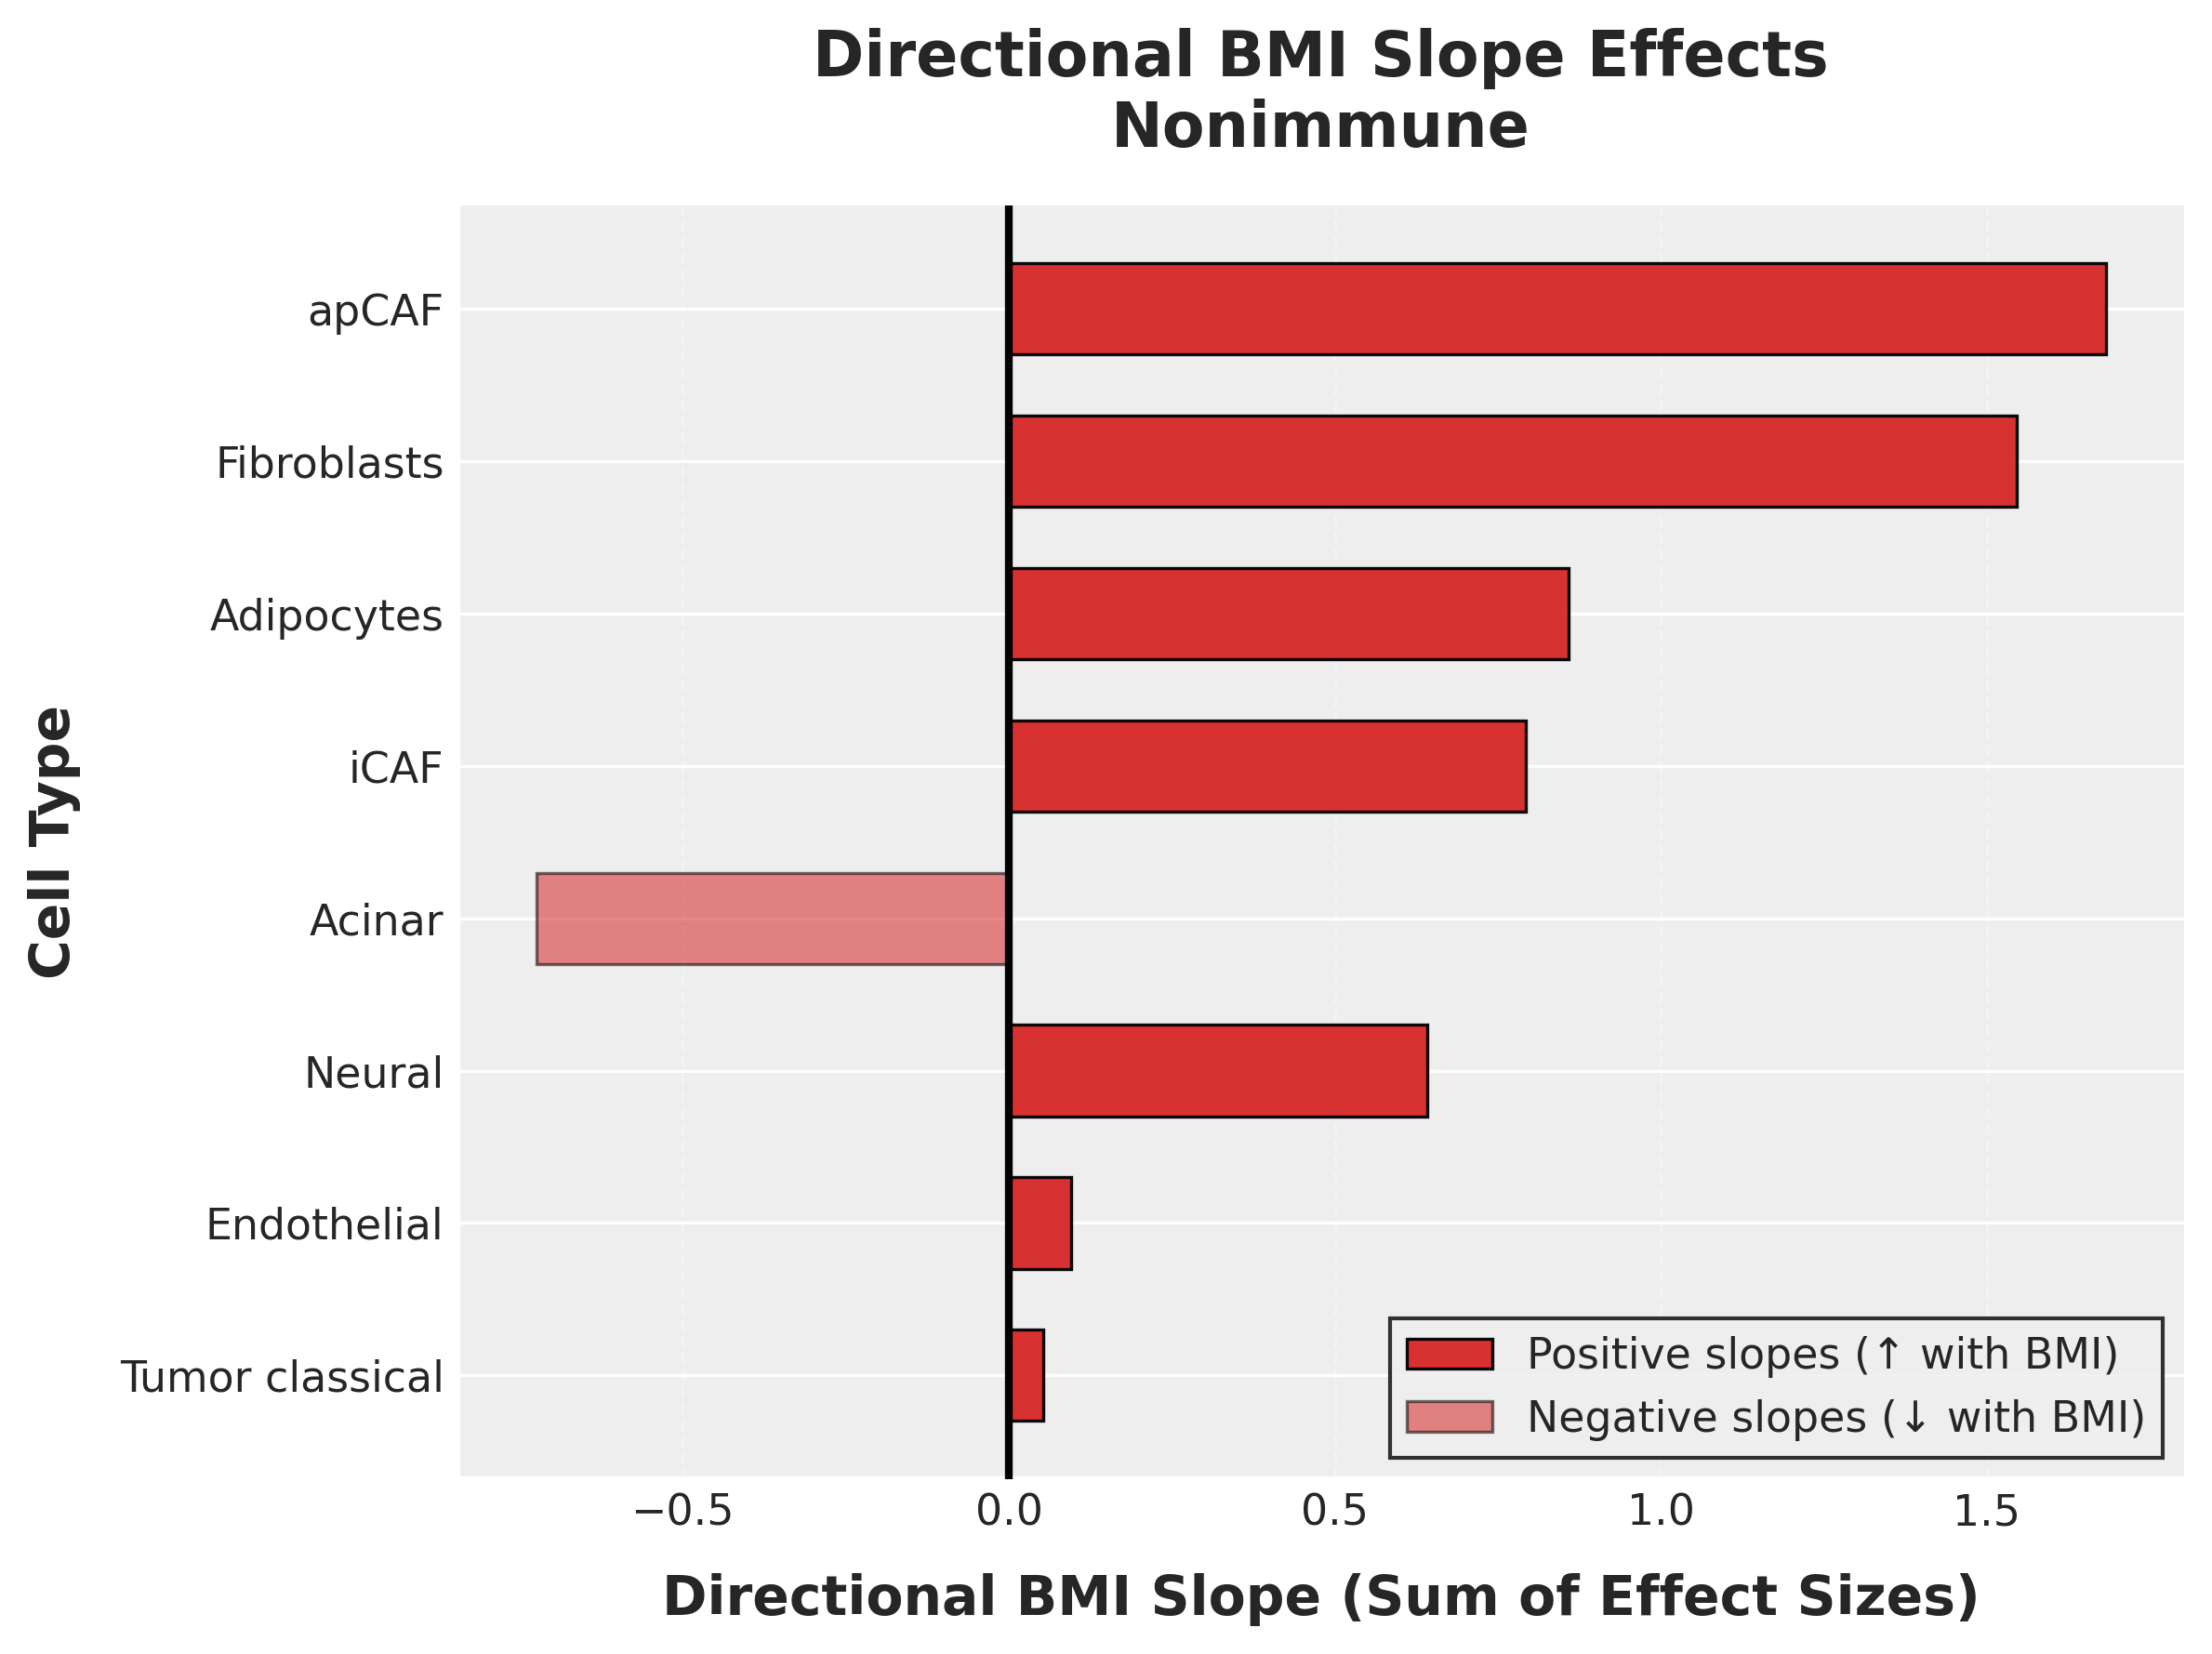


  Summary for nonimmune:
    Tumor classical: 2 positive, 0 negative features
    Endothelial: 1 positive, 0 negative features
    Neural: 6 positive, 0 negative features
    Acinar: 0 positive, 6 negative features
    iCAF: 24 positive, 0 negative features
    Adipocytes: 18 positive, 0 negative features
    Fibroblasts: 33 positive, 0 negative features
    apCAF: 14 positive, 0 negative features

COMPARTMENT: Immune Fine (immune_fine)
  ✅ Loading: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_fine/bayesian_results_continuous_with_rope.csv
  Rows loaded: 156
  ✅ Filtered to 94 rows. Cells: ['B cells naive', 'CD4 T Th1', 'CD4 T naive', 'CD4 T regulatory', 'CD8 T exhausted', 'CD8 Tmemory', 'Monocyte classical', 'Monocyte non-classical']

  Creating directional BMI slope plot...
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_fine/continuous_publication_figures/stacked_bar_plots/bmi_slope_directional_immune_f

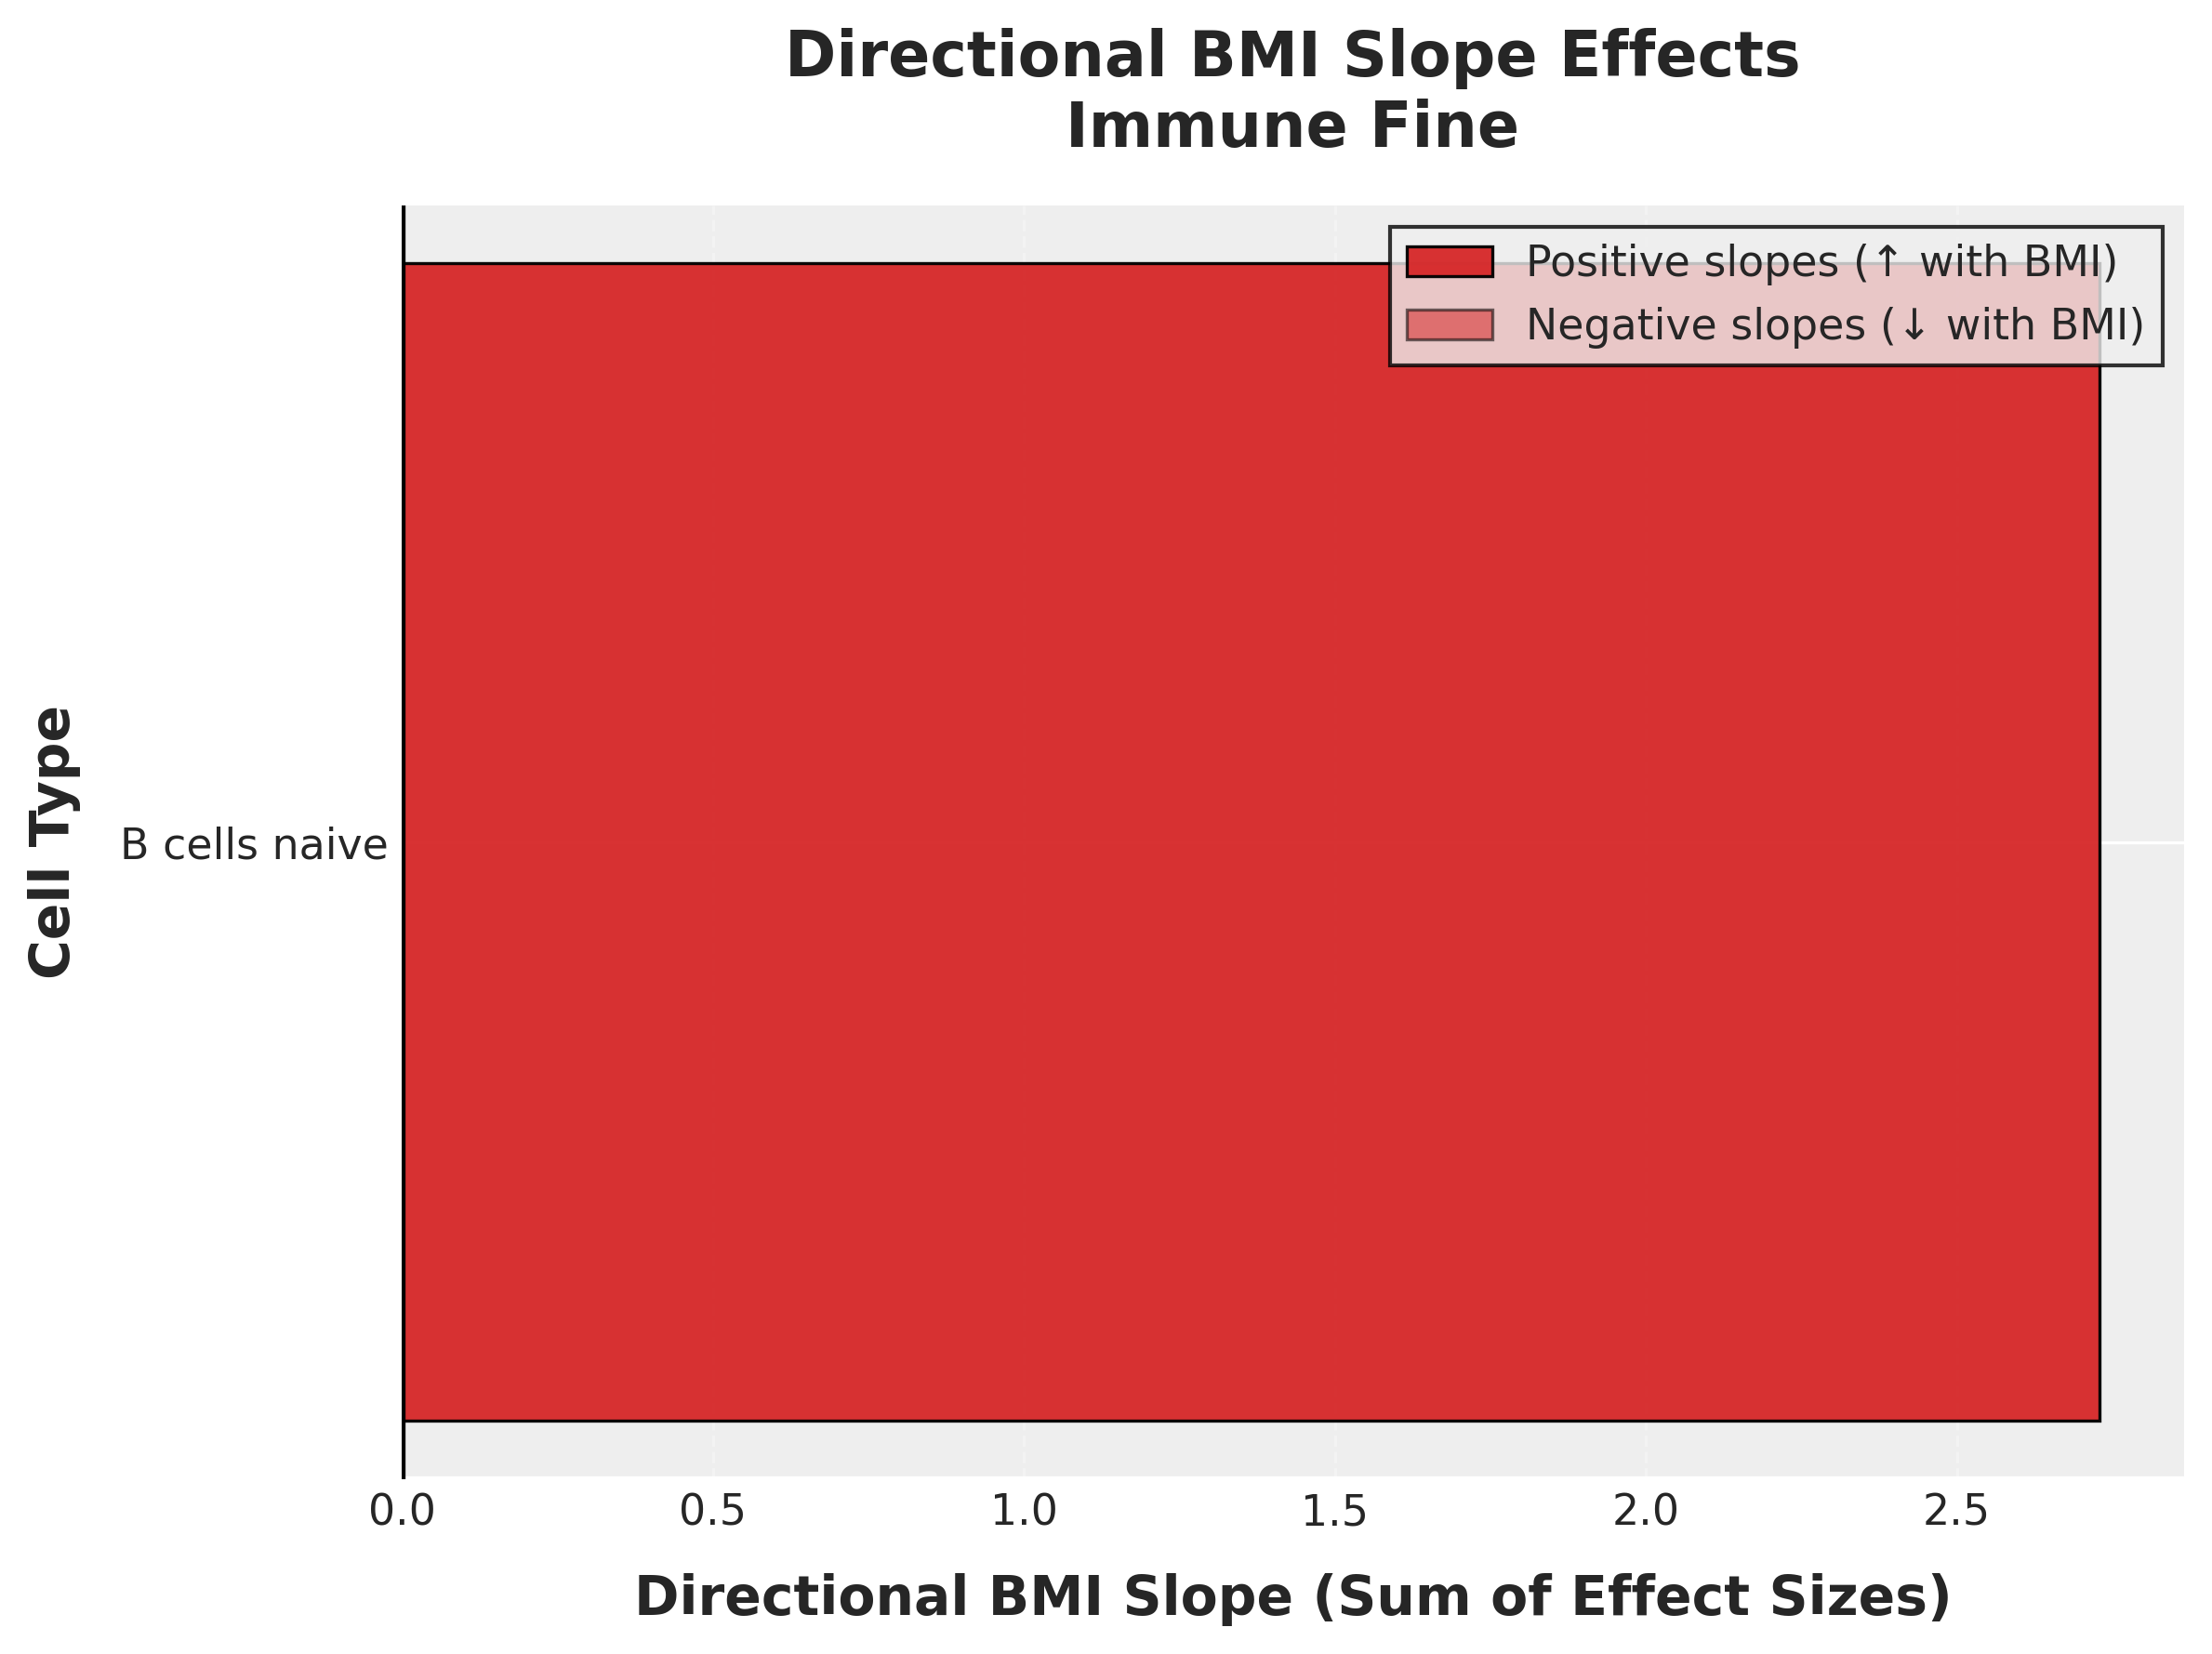


  Summary for immune_fine:
    B cells naive: 16 positive, 0 negative features

COMPARTMENT: Immune Coarse (immune_coarse)
  ✅ Loading: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_coarse/bayesian_results_continuous_with_rope.csv
  Rows loaded: 167
  ✅ Filtered to 167 rows. Cells: ['B cells', 'Basophils', 'CD4+ T cells', 'CD8 T general', 'Dendritic cells', 'Monocytes', 'NK cells', 'T cells']

  Creating directional BMI slope plot...
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_coarse/continuous_publication_figures/stacked_bar_plots/bmi_slope_directional_immune_coarse.png
  ✅ Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/stacked_bar_plots/immune_coarse/bmi_slope_directional_immune_coarse.svg


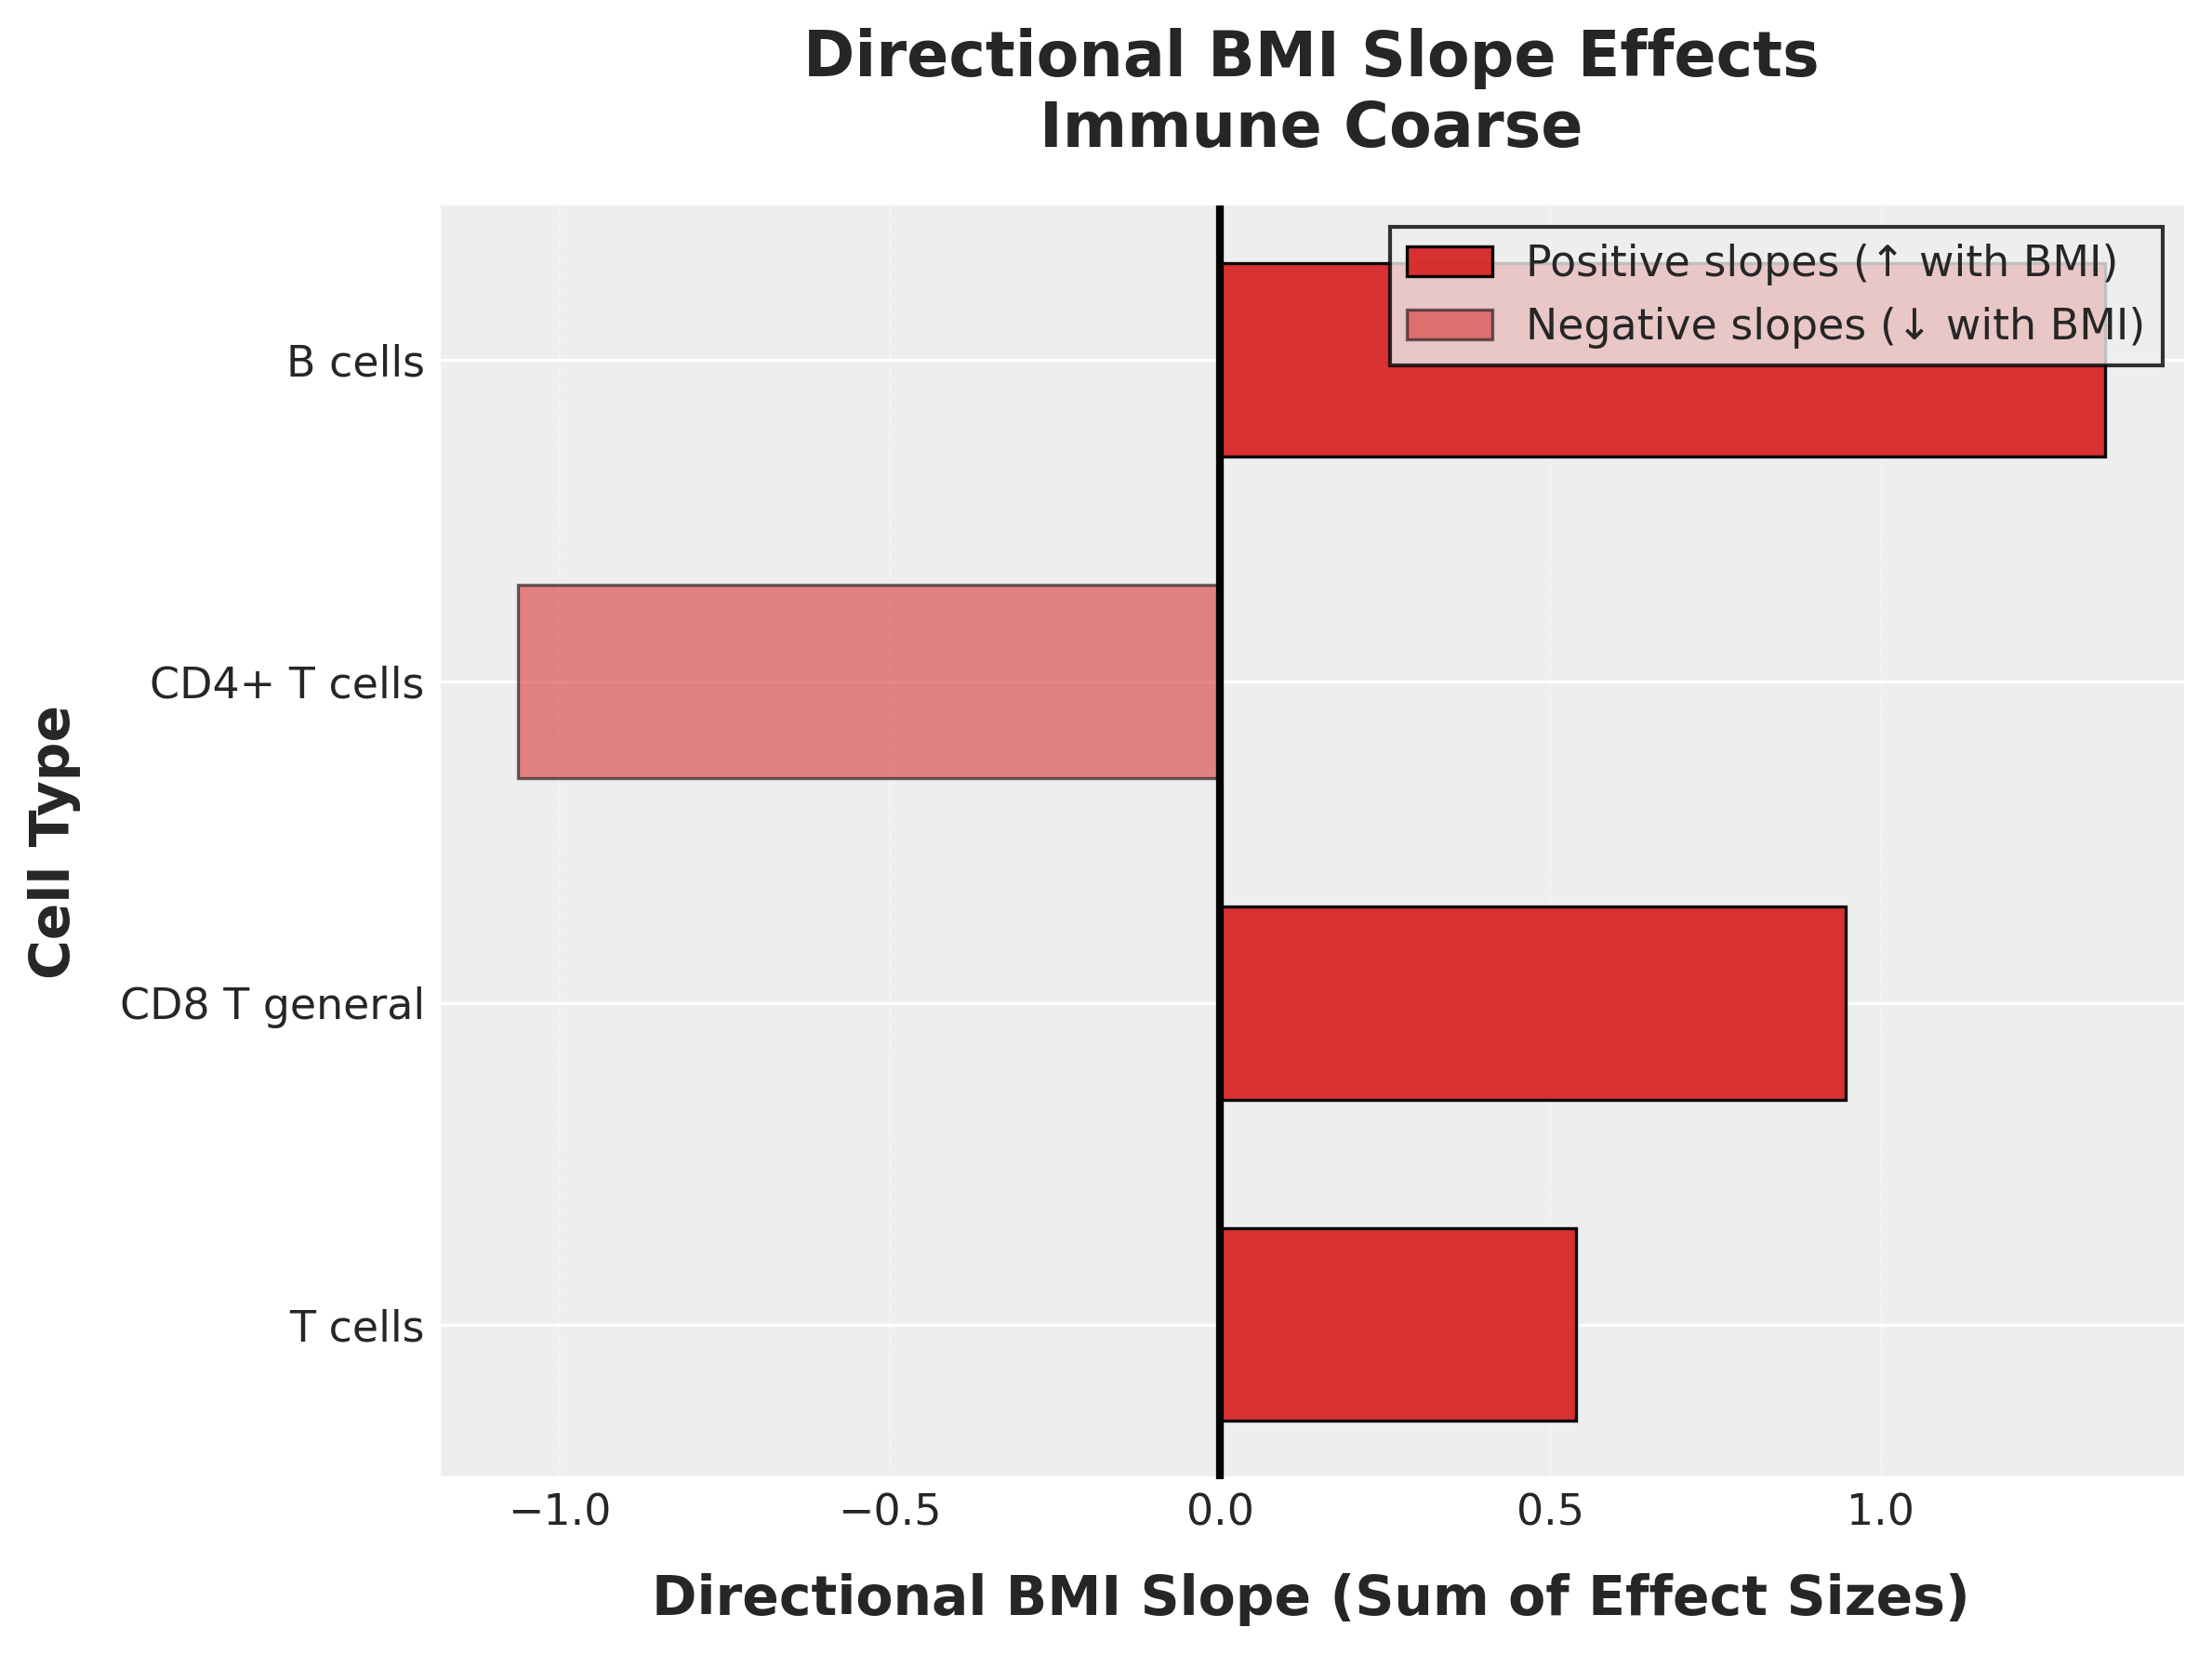


  Summary for immune_coarse:
    T cells: 8 positive, 0 negative features
    CD8 T general: 12 positive, 0 negative features
    CD4+ T cells: 0 positive, 13 negative features
    B cells: 9 positive, 0 negative features

✅ ALL COMPARTMENTS COMPLETED

OUTPUT LOCATIONS:

Non-Immune:
  PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune/continuous_publication_figures/stacked_bar_plots
  SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/stacked_bar_plots/nonimmune

Immune Fine:
  PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_fine/continuous_publication_figures/stacked_bar_plots
  SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/stacked_bar_plots/immune_fine

Immune Coarse:
  PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_coarse/continuous_publication_figures/stacked_bar_plots
  SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/stacked_bar_plots/immune

In [ ]:
#!/usr/bin/env python3
"""
Directional BMI Slope Effect-Size Plot (Positive vs Negative)
CONTINUOUS BMI VERSION

Shows sum of credible BMI slopes per cell type:
- Positive bars: Sum of positive slopes (features increasing with BMI)
- Negative bars: Sum of negative slopes (features decreasing with BMI)
"""

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# CONFIG
# -----------------------------
BASE = "/content/drive/MyDrive/new_dysfunction"

# SVG output configuration
SVG_BASE = f"{BASE}/svg_continuous"
SVG_SUBFOLDER = "stacked_bar_plots"

# -----------------------------
# AESTHETICS
# -----------------------------
FIGURE_WIDTH = 8
FIGURE_HEIGHT = 6
FIGURE_DPI = 300
BAR_WIDTH = 0.6
BAR_ALPHA_POS = 0.95  # Positive slopes (solid)
BAR_ALPHA_NEG = 0.55  # Negative slopes (transparent)
BAR_EDGE_LINEWIDTH = 0.8

FONT_SIZE_BASE = 9
FONT_SIZE_TITLE = 16
FONT_SIZE_LABEL = 14
FONT_SIZE_TICK = 11
FONT_SIZE_LEGEND = 11

AXES_LINEWIDTH = 1.5
GRID_ALPHA = 0.3
GRID_LINESTYLE = '--'

# Colors for BMI slope
BMI_SLOPE_COLOR = "#D62728"  # Red (consistent with other continuous plots)

plt.rcParams.update({
    "figure.dpi": FIGURE_DPI,
    "savefig.dpi": FIGURE_DPI,
    "font.size": FONT_SIZE_BASE,
    "font.family": "DejaVu Sans",
    "axes.titlesize": FONT_SIZE_TITLE,
    "axes.labelsize": FONT_SIZE_LABEL,
    "xtick.labelsize": FONT_SIZE_TICK,
    "ytick.labelsize": FONT_SIZE_TICK,
    "axes.linewidth": AXES_LINEWIDTH,
})

# -----------------------------
# COMPARTMENTS + CELL_GROUPS
# -----------------------------
COMPARTMENTS = {
    'nonimmune': {
        'dir': f"{BASE}/bayesian_hierarchical_continuous_nonimmune",
        'name': 'Non-Immune'
    },
    'immune_fine': {
        'dir': f"{BASE}/bayesian_hierarchical_continuous_immune_fine",
        'name': 'Immune Fine'
    },
    'immune_coarse': {
        'dir': f"{BASE}/bayesian_hierarchical_continuous_immune_coarse",
        'name': 'Immune Coarse'
    }
}

CELL_GROUPS = {
    "nonimmune": {
        "Acinar", "Adipocytes", "Endothelial", "Fibroblasts",
        "Islet endocrine", "Neural", "Normal ductal", "Pericytes SMC",
        "Schwann", "Stellate", "Tumor classical", "Tumor epithelial",
        "apCAF", "iCAF"
    },
    "immune_fine": {
        "B cells naive", "CD4 T Th1", "CD4 T naive", "CD4 T regulatory", "CD4 Tfh",
        "CD8 T effector", "CD8 T exhausted", "CD8 Tmemory",
        "Monocyte classical", "Monocyte non-classical",
        "T gamma delta", "TAM", "mDC", "pDC"
    },
    "immune_coarse": {
        "B cells", "Basophils", "CD4+ T cells", "CD8 T general",
        "Dendritic cells", "Monocytes", "NK cells", "T cells"
    }
}

# -----------------------------
# HELPERS
# -----------------------------
def parse_feature(feature):
    if "||" in feature:
        cell_type, signature = feature.split("||", 1)
        cell_type = cell_type.replace("_", " ")
        signature = re.sub(r"_Signature$", "", signature).replace("_", " ")
        return cell_type, signature
    return "Unknown", feature.replace("_", " ")

def canon_cell(cell_like):
    s = str(cell_like).strip()
    s = re.sub(r"[_\-]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()

    ALIASES = {
        "acinar": "Acinar", "adipocytes": "Adipocytes", "b cells": "B cells",
        "b cells naive": "B cells naive", "basophils": "Basophils",
        "cd4+ t cells": "CD4+ T cells", "cd8 t general": "CD8 T general",
        "endothelial": "Endothelial", "fibroblasts": "Fibroblasts",
        "islet endocrine": "Islet endocrine", "neural": "Neural",
        "normal ductal": "Normal ductal", "pericytes smc": "Pericytes SMC",
        "schwann": "Schwann", "stellate": "Stellate",
        "tumor classical": "Tumor classical", "tumor epithelial": "Tumor epithelial",
        "apcaf": "apCAF", "icaf": "iCAF",
        "cd4 t th1": "CD4 T Th1", "cd4 t naive": "CD4 T naive",
        "cd4 t regulatory": "CD4 T regulatory", "cd4 tfh": "CD4 Tfh",
        "cd8 t effector": "CD8 T effector", "cd8 t exhausted": "CD8 T exhausted",
        "cd8 tmemory": "CD8 Tmemory",
        "monocyte classical": "Monocyte classical",
        "monocyte non classical": "Monocyte non-classical",
        "t gamma delta": "T gamma delta", "tam": "TAM",
        "mdc": "mDC", "pdc": "pDC",
        "dendritic cells": "Dendritic cells", "monocytes": "Monocytes",
        "nk cells": "NK cells", "t cells": "T cells"
    }
    return ALIASES.get(s.lower(), s)

# -----------------------------
# CORE FUNCTION
# -----------------------------
def create_bmi_slope_directional_plot(df, out_base, svg_out_base, out_fname_suffix):
    """
    Create directional effect-size plot for continuous BMI slopes.

    Shows:
    - Positive bars: Sum of positive BMI slopes (features increasing with BMI)
    - Negative bars: Sum of negative BMI slopes (features decreasing with BMI)
    """
    df = df.copy()

    if 'feature' not in df.columns:
        raise ValueError("Input CSV must have a 'feature' column.")

    # Parse cell types
    df['cell_type_parsed'], df['signature'] = zip(*df['feature'].apply(parse_feature))
    df['cell_canon'] = df['cell_type_parsed'].apply(canon_cell)

    # Column names for continuous BMI
    mean_col = 'bmi_slope_standardized_mean'
    cred_col = 'bmi_slope_credible'

    if mean_col not in df.columns or cred_col not in df.columns:
        print(f"    ⚠️  Missing columns: {mean_col} or {cred_col}")
        return

    # Filter to credible slopes only
    df_credible = df[df[cred_col].astype(bool)].copy()

    if df_credible.empty:
        print(f"    ℹ️  No credible BMI slopes found for {out_fname_suffix}")
        return

    # Calculate directional sums per cell type
    records = []
    for ct in df_credible['cell_canon'].unique():
        ct_df = df_credible[df_credible['cell_canon'] == ct]

        # Sum of positive slopes
        pos_sum = ct_df[ct_df[mean_col] > 0][mean_col].sum()

        # Sum of negative slopes (absolute value for plotting)
        neg_sum = ct_df[ct_df[mean_col] < 0][mean_col].sum()

        # Count features
        n_pos = (ct_df[mean_col] > 0).sum()
        n_neg = (ct_df[mean_col] < 0).sum()

        records.append({
            'cell_canon': ct,
            'pos_sum': pos_sum,
            'neg_sum': neg_sum,
            'n_pos': n_pos,
            'n_neg': n_neg
        })

    if not records:
        print(f"  ⚠️  No directional data found for {out_fname_suffix}")
        return

    effect_df = pd.DataFrame.from_records(records)

    # Sort by total magnitude
    effect_df['total_mag'] = effect_df['pos_sum'] + abs(effect_df['neg_sum'])
    effect_df = effect_df.sort_values('total_mag', ascending=True)

    # Create plot
    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT), dpi=FIGURE_DPI)

    y_positions = np.arange(len(effect_df))

    # Plot positive slopes (right side, solid)
    ax.barh(y_positions, effect_df['pos_sum'], BAR_WIDTH,
            color=BMI_SLOPE_COLOR, alpha=BAR_ALPHA_POS,
            edgecolor='black', linewidth=BAR_EDGE_LINEWIDTH,
            label='Positive slopes (↑ with BMI)')

    # Plot negative slopes (left side, transparent)
    ax.barh(y_positions, effect_df['neg_sum'], BAR_WIDTH,
            color=BMI_SLOPE_COLOR, alpha=BAR_ALPHA_NEG,
            edgecolor='black', linewidth=BAR_EDGE_LINEWIDTH,
            label='Negative slopes (↓ with BMI)')

    # Labels
    ax.set_yticks(y_positions)
    ax.set_yticklabels(effect_df['cell_canon'], fontsize=FONT_SIZE_TICK)
    ax.set_ylabel('Cell Type', fontsize=FONT_SIZE_LABEL, fontweight='bold', labelpad=10)
    ax.set_xlabel('Directional BMI Slope (Sum of Effect Sizes)',
                  fontsize=FONT_SIZE_LABEL, fontweight='bold', labelpad=10)

    ax.set_title(f'Directional BMI Slope Effects\n{out_fname_suffix.replace("_", " ").title()}',
                 fontsize=FONT_SIZE_TITLE, fontweight='bold', pad=15)

    # Styling
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=GRID_ALPHA, linestyle=GRID_LINESTYLE)
    ax.axvline(0, color='black', linewidth=2, zorder=5)

    # Legend
    ax.legend(loc='best', fontsize=FONT_SIZE_LEGEND, frameon=True,
              edgecolor='black', fancybox=False)

    plt.tight_layout()

    # Save PNG
    outfile = os.path.join(out_base, f"bmi_slope_directional_{out_fname_suffix}.png")
    plt.savefig(outfile, dpi=FIGURE_DPI, bbox_inches="tight", facecolor='white')
    print(f"  ✅ Saved PNG: {outfile}")

    # Save SVG
    svg_outfile = os.path.join(svg_out_base, f"bmi_slope_directional_{out_fname_suffix}.svg")
    plt.savefig(svg_outfile, format='svg', bbox_inches="tight", facecolor='white')
    print(f"  ✅ Saved SVG: {svg_outfile}")

    plt.show()
    plt.close(fig)

    # Print summary
    print(f"\n  Summary for {out_fname_suffix}:")
    for _, row in effect_df.iterrows():
        print(f"    {row['cell_canon']}: {row['n_pos']} positive, {row['n_neg']} negative features")

# -----------------------------
# RUN PER COMPARTMENT
# -----------------------------
print("="*80)
print("DIRECTIONAL BMI SLOPE PLOTS (CONTINUOUS MODEL)")
print("="*80)

for comp_key, info in COMPARTMENTS.items():
    comp_name = info['name']
    comp_dir = info['dir']

    print("\n" + "="*60)
    print(f"COMPARTMENT: {comp_name} ({comp_key})")

    # Load compartment-specific results file
    results_csv = os.path.join(comp_dir, "bayesian_results_continuous_with_rope.csv")

    if not os.path.exists(results_csv):
        print(f"  ❌ Results file not found: {results_csv}")
        continue

    print(f"  ✅ Loading: {results_csv}")
    df = pd.read_csv(results_csv)
    print(f"  Rows loaded: {len(df)}")

    # Parse cell types
    if 'cell_type' in df.columns and df['cell_type'].notna().any():
        df['cell_type_parsed'] = df['cell_type']
        df['signature'] = df['feature'].apply(lambda f: parse_feature(f)[1])
    else:
        df['cell_type_parsed'], df['signature'] = zip(*df['feature'].apply(parse_feature))

    df['cell_canon'] = df['cell_type_parsed'].apply(canon_cell)

    # Filter by cell groups
    wanted = CELL_GROUPS.get(comp_key, None)
    if wanted is not None:
        filtered = df[df['cell_canon'].isin(wanted)].copy()
        if filtered.empty:
            print(f"  ⚠️  After filtering, 0 rows remain — skipping {comp_key}.")
            continue
        else:
            print(f"  ✅ Filtered to {len(filtered)} rows. Cells: {sorted(filtered['cell_canon'].unique())}")
        df_to_plot = filtered
    else:
        df_to_plot = df

    # Create output directories
    out_dir = os.path.join(comp_dir, "continuous_publication_figures", "stacked_bar_plots")
    os.makedirs(out_dir, exist_ok=True)

    svg_out_dir = os.path.join(SVG_BASE, SVG_SUBFOLDER, comp_key)
    os.makedirs(svg_out_dir, exist_ok=True)

    print(f"\n  Creating directional BMI slope plot...")
    create_bmi_slope_directional_plot(df_to_plot, out_dir, svg_out_dir, comp_key)

print("\n" + "="*80)
print("✅ ALL COMPARTMENTS COMPLETED")
print("="*80)

# Print output summary
print("\nOUTPUT LOCATIONS:")
for comp_key, info in COMPARTMENTS.items():
    comp_dir = info['dir']
    png_dir = os.path.join(comp_dir, "continuous_publication_figures", "stacked_bar_plots")
    svg_dir = os.path.join(SVG_BASE, SVG_SUBFOLDER, comp_key)

    print(f"\n{info['name']}:")
    print(f"  PNG: {png_dir}")
    print(f"  SVG: {svg_dir}")

##Stacekd bar plot counts

STACKED BAR PLOTS - CONTINUOUS BMI SLOPES

COMPARTMENT: Non-Immune (nonimmune)
  ✅ Loading: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune/bayesian_results_continuous_with_rope.csv
  Rows loaded: 249
  [Non-Immune] Prepared 249 rows
    [Non-Immune] BMI slope: 104 credible features
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune/continuous_publication_figures/stacked_bar_plots/bmi_slope_count_Non-Immune.png
  ✅ Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/stacked_bar_plots/nonimmune/bmi_slope_count_Non-Immune.svg


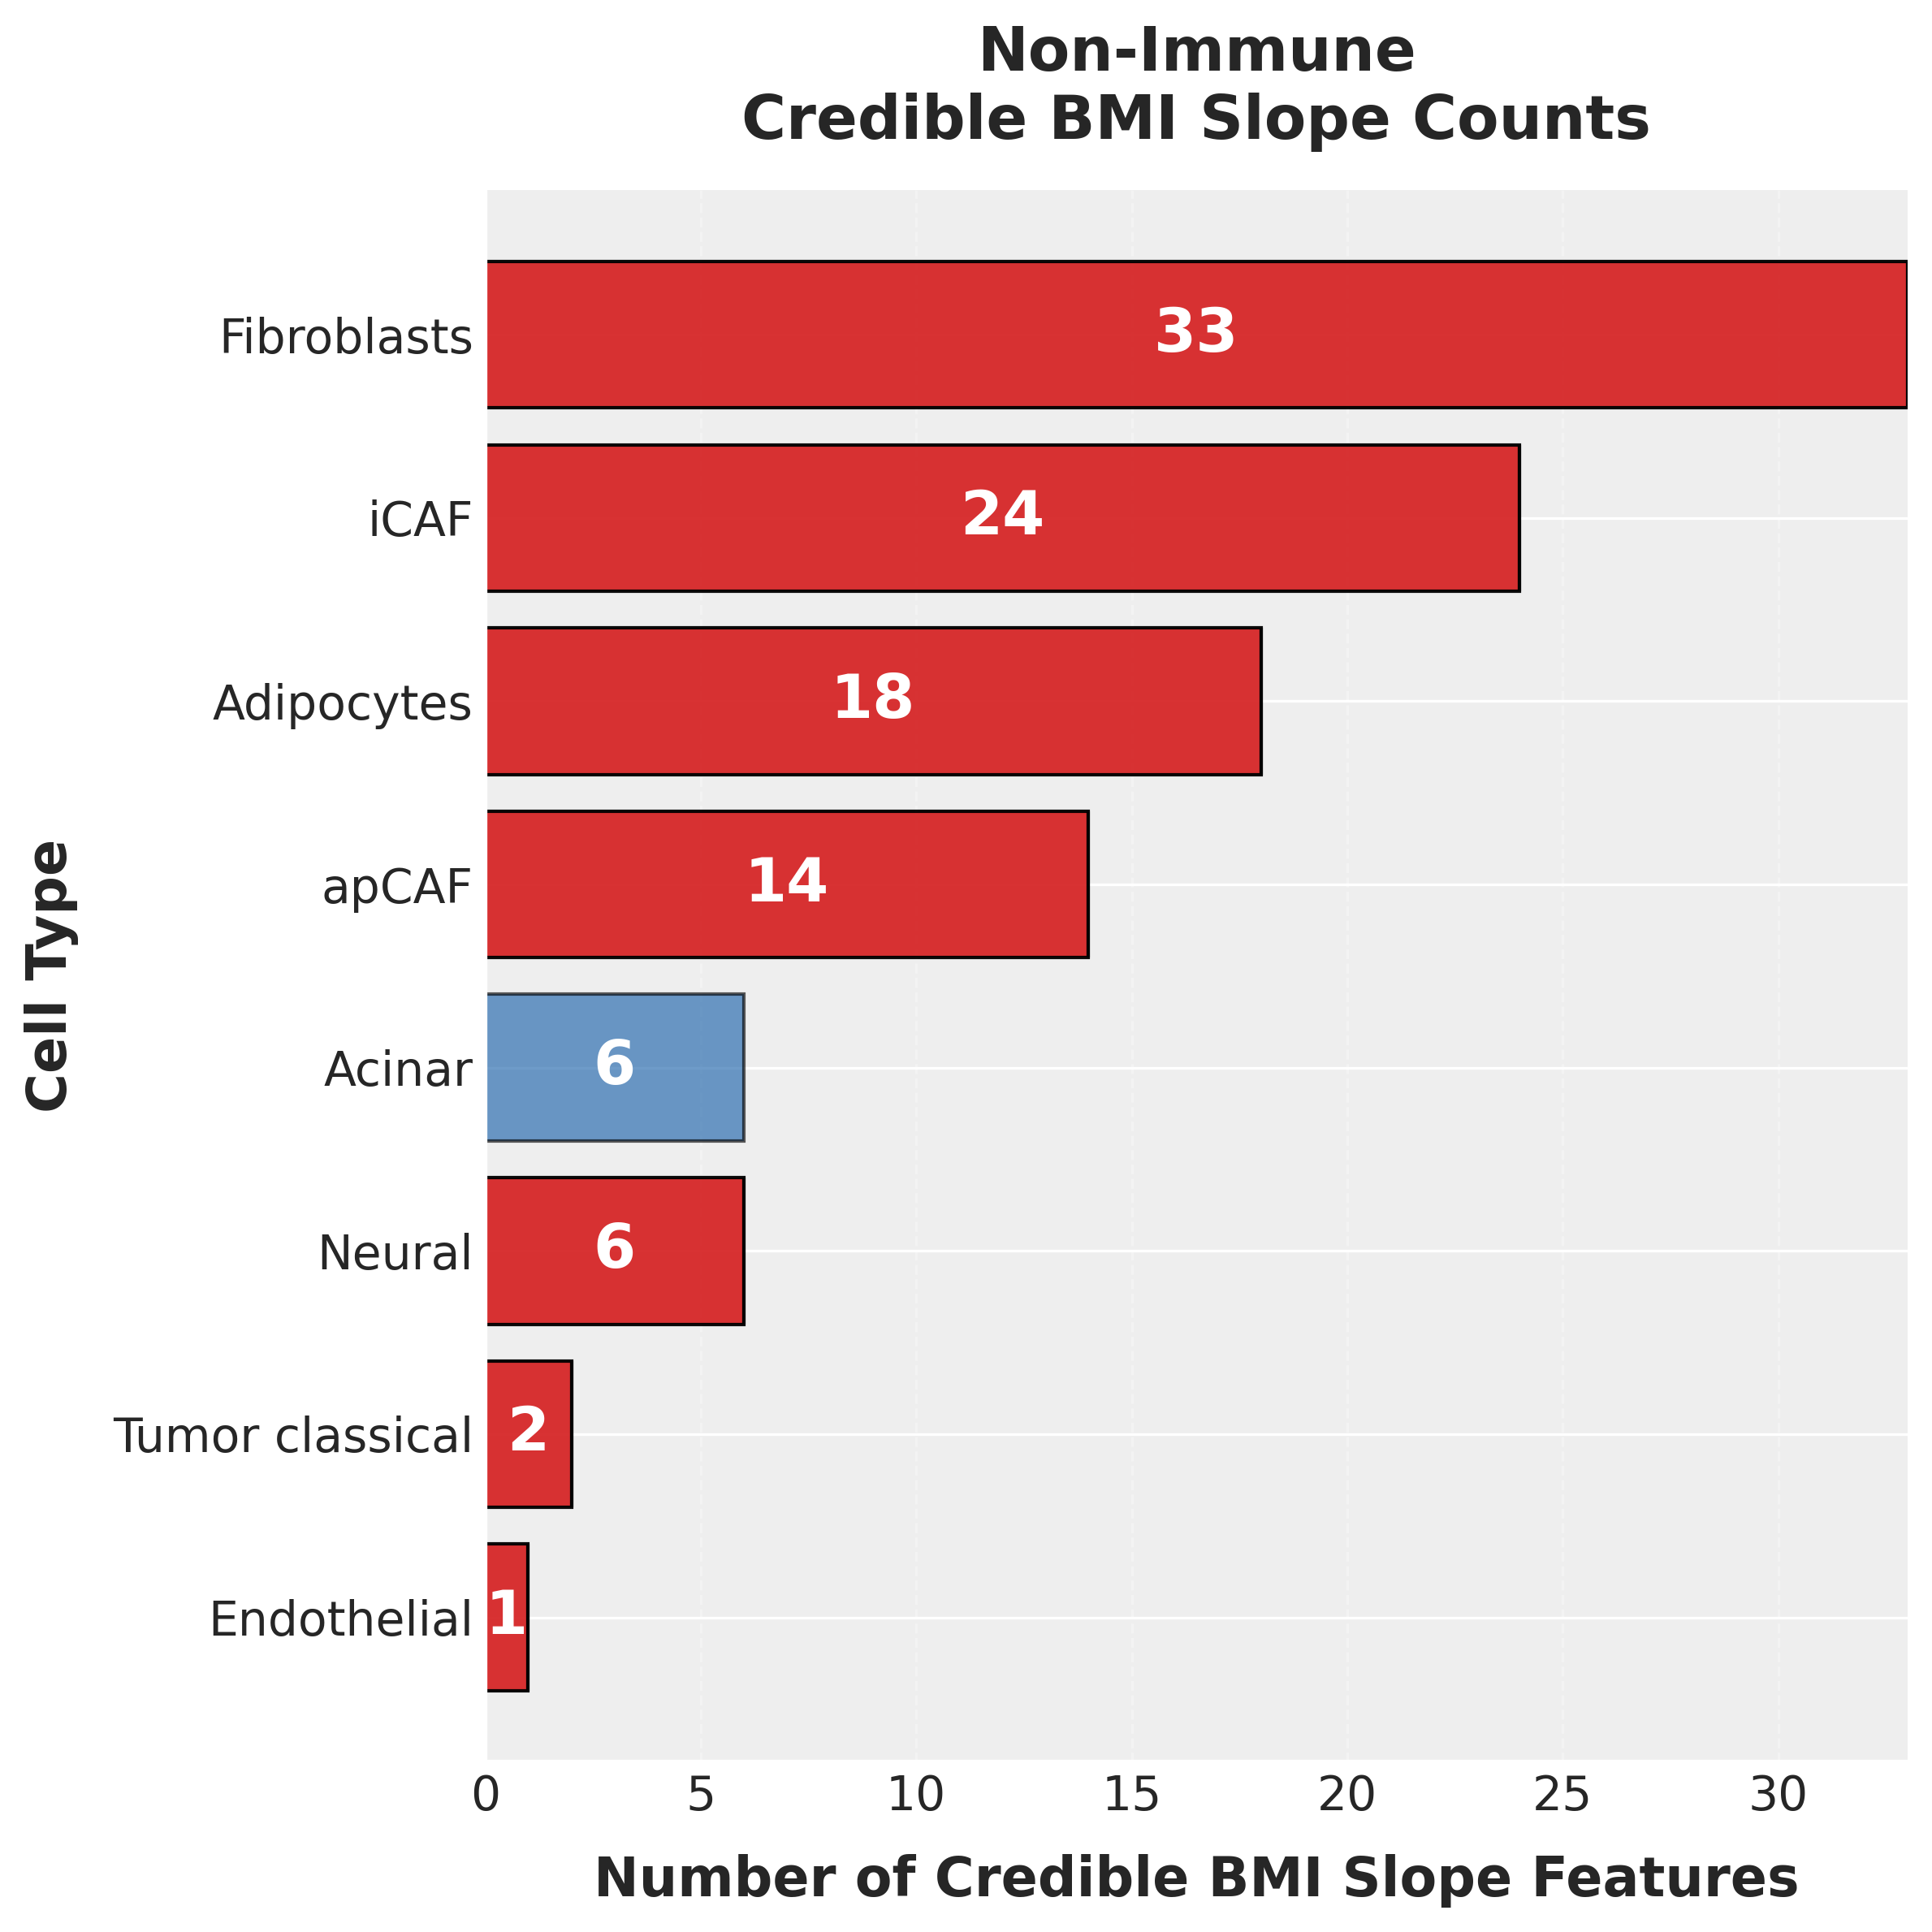

  ✅ Saved legend PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune/continuous_publication_figures/stacked_bar_plots/legend_bmi_slopes_Non-Immune.png
  ✅ Saved legend SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/stacked_bar_plots/nonimmune/legend_bmi_slopes_Non-Immune.svg


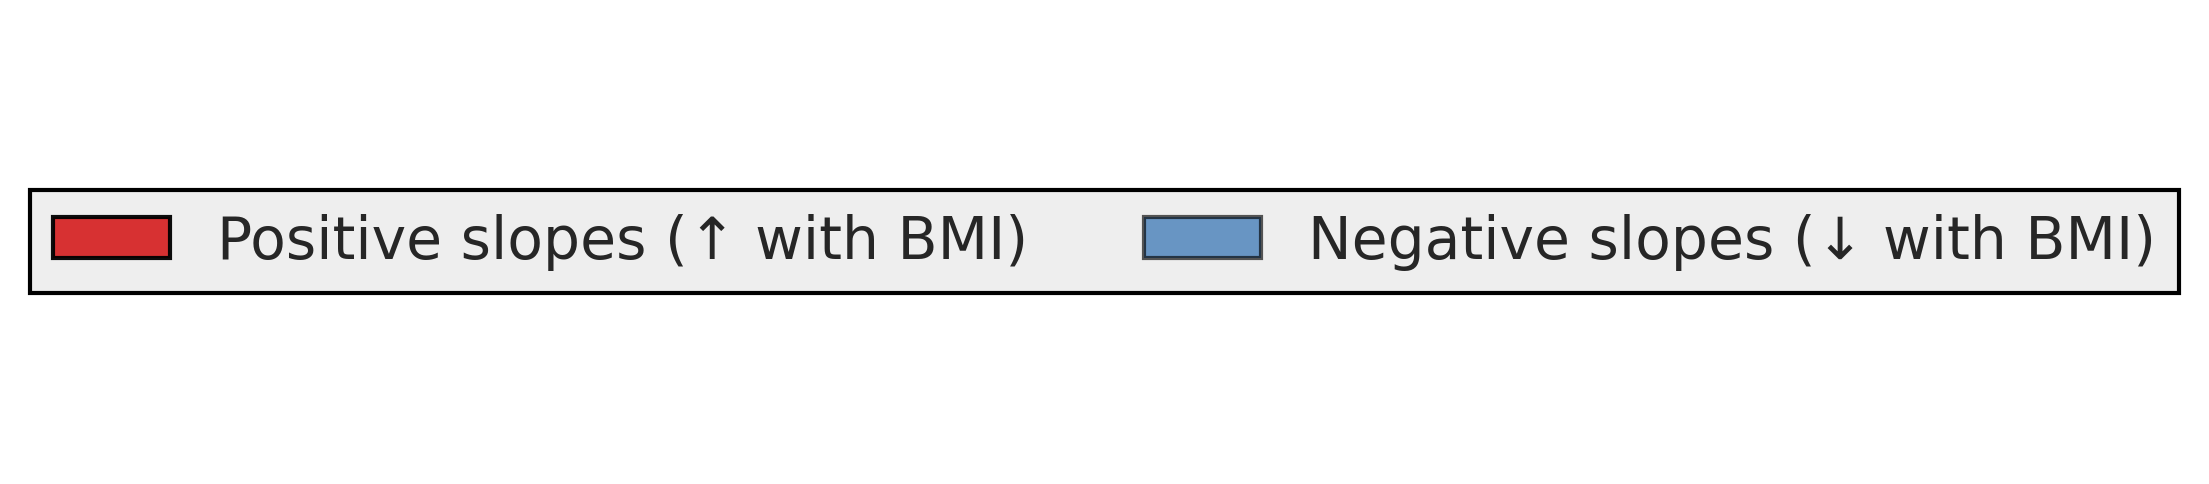

  [Non-Immune] Prepared 249 rows
    [Non-Immune] Effect size: 104 credible features
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_nonimmune/continuous_publication_figures/stacked_bar_plots/bmi_slope_effect_size_Non-Immune.png
  ✅ Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/stacked_bar_plots/nonimmune/bmi_slope_effect_size_Non-Immune.svg


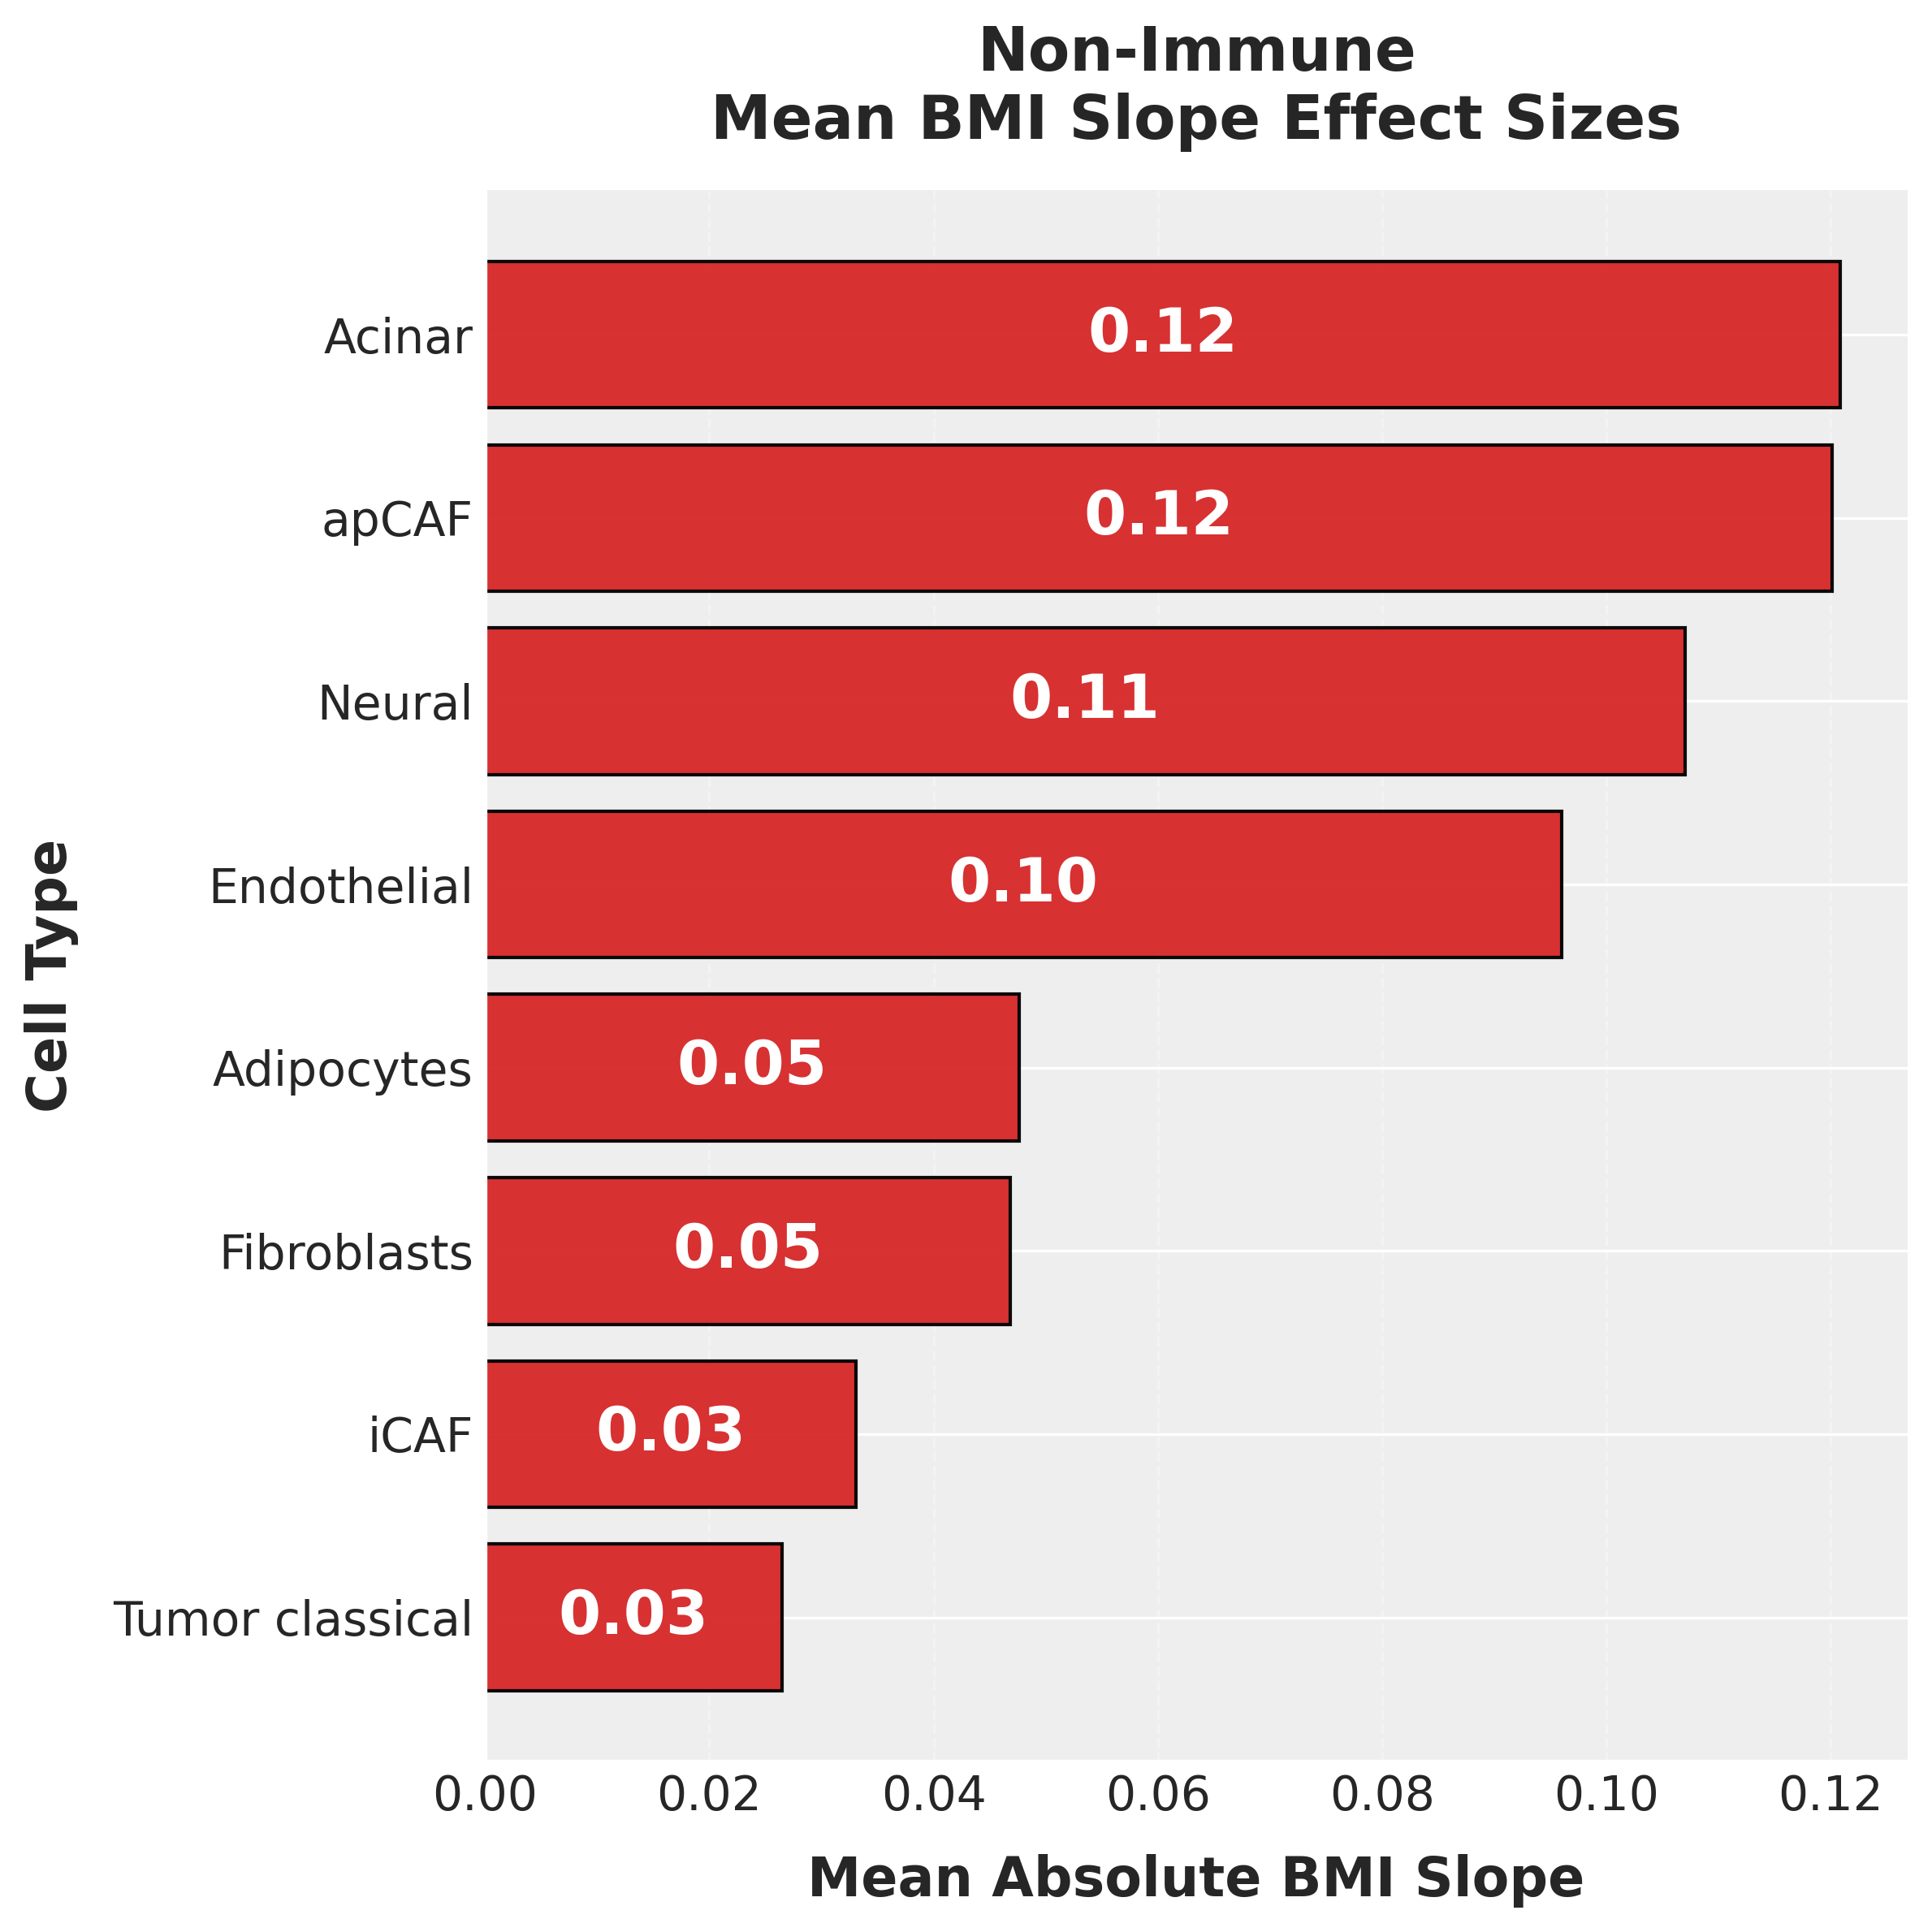


COMPARTMENT: Immune Fine (immune_fine)
  ✅ Loading: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_fine/bayesian_results_continuous_with_rope.csv
  Rows loaded: 156
  [Immune Fine] Prepared 156 rows
    [Immune Fine] BMI slope: 37 credible features
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_fine/continuous_publication_figures/stacked_bar_plots/bmi_slope_count_Immune_Fine.png
  ✅ Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/stacked_bar_plots/immune_fine/bmi_slope_count_Immune_Fine.svg


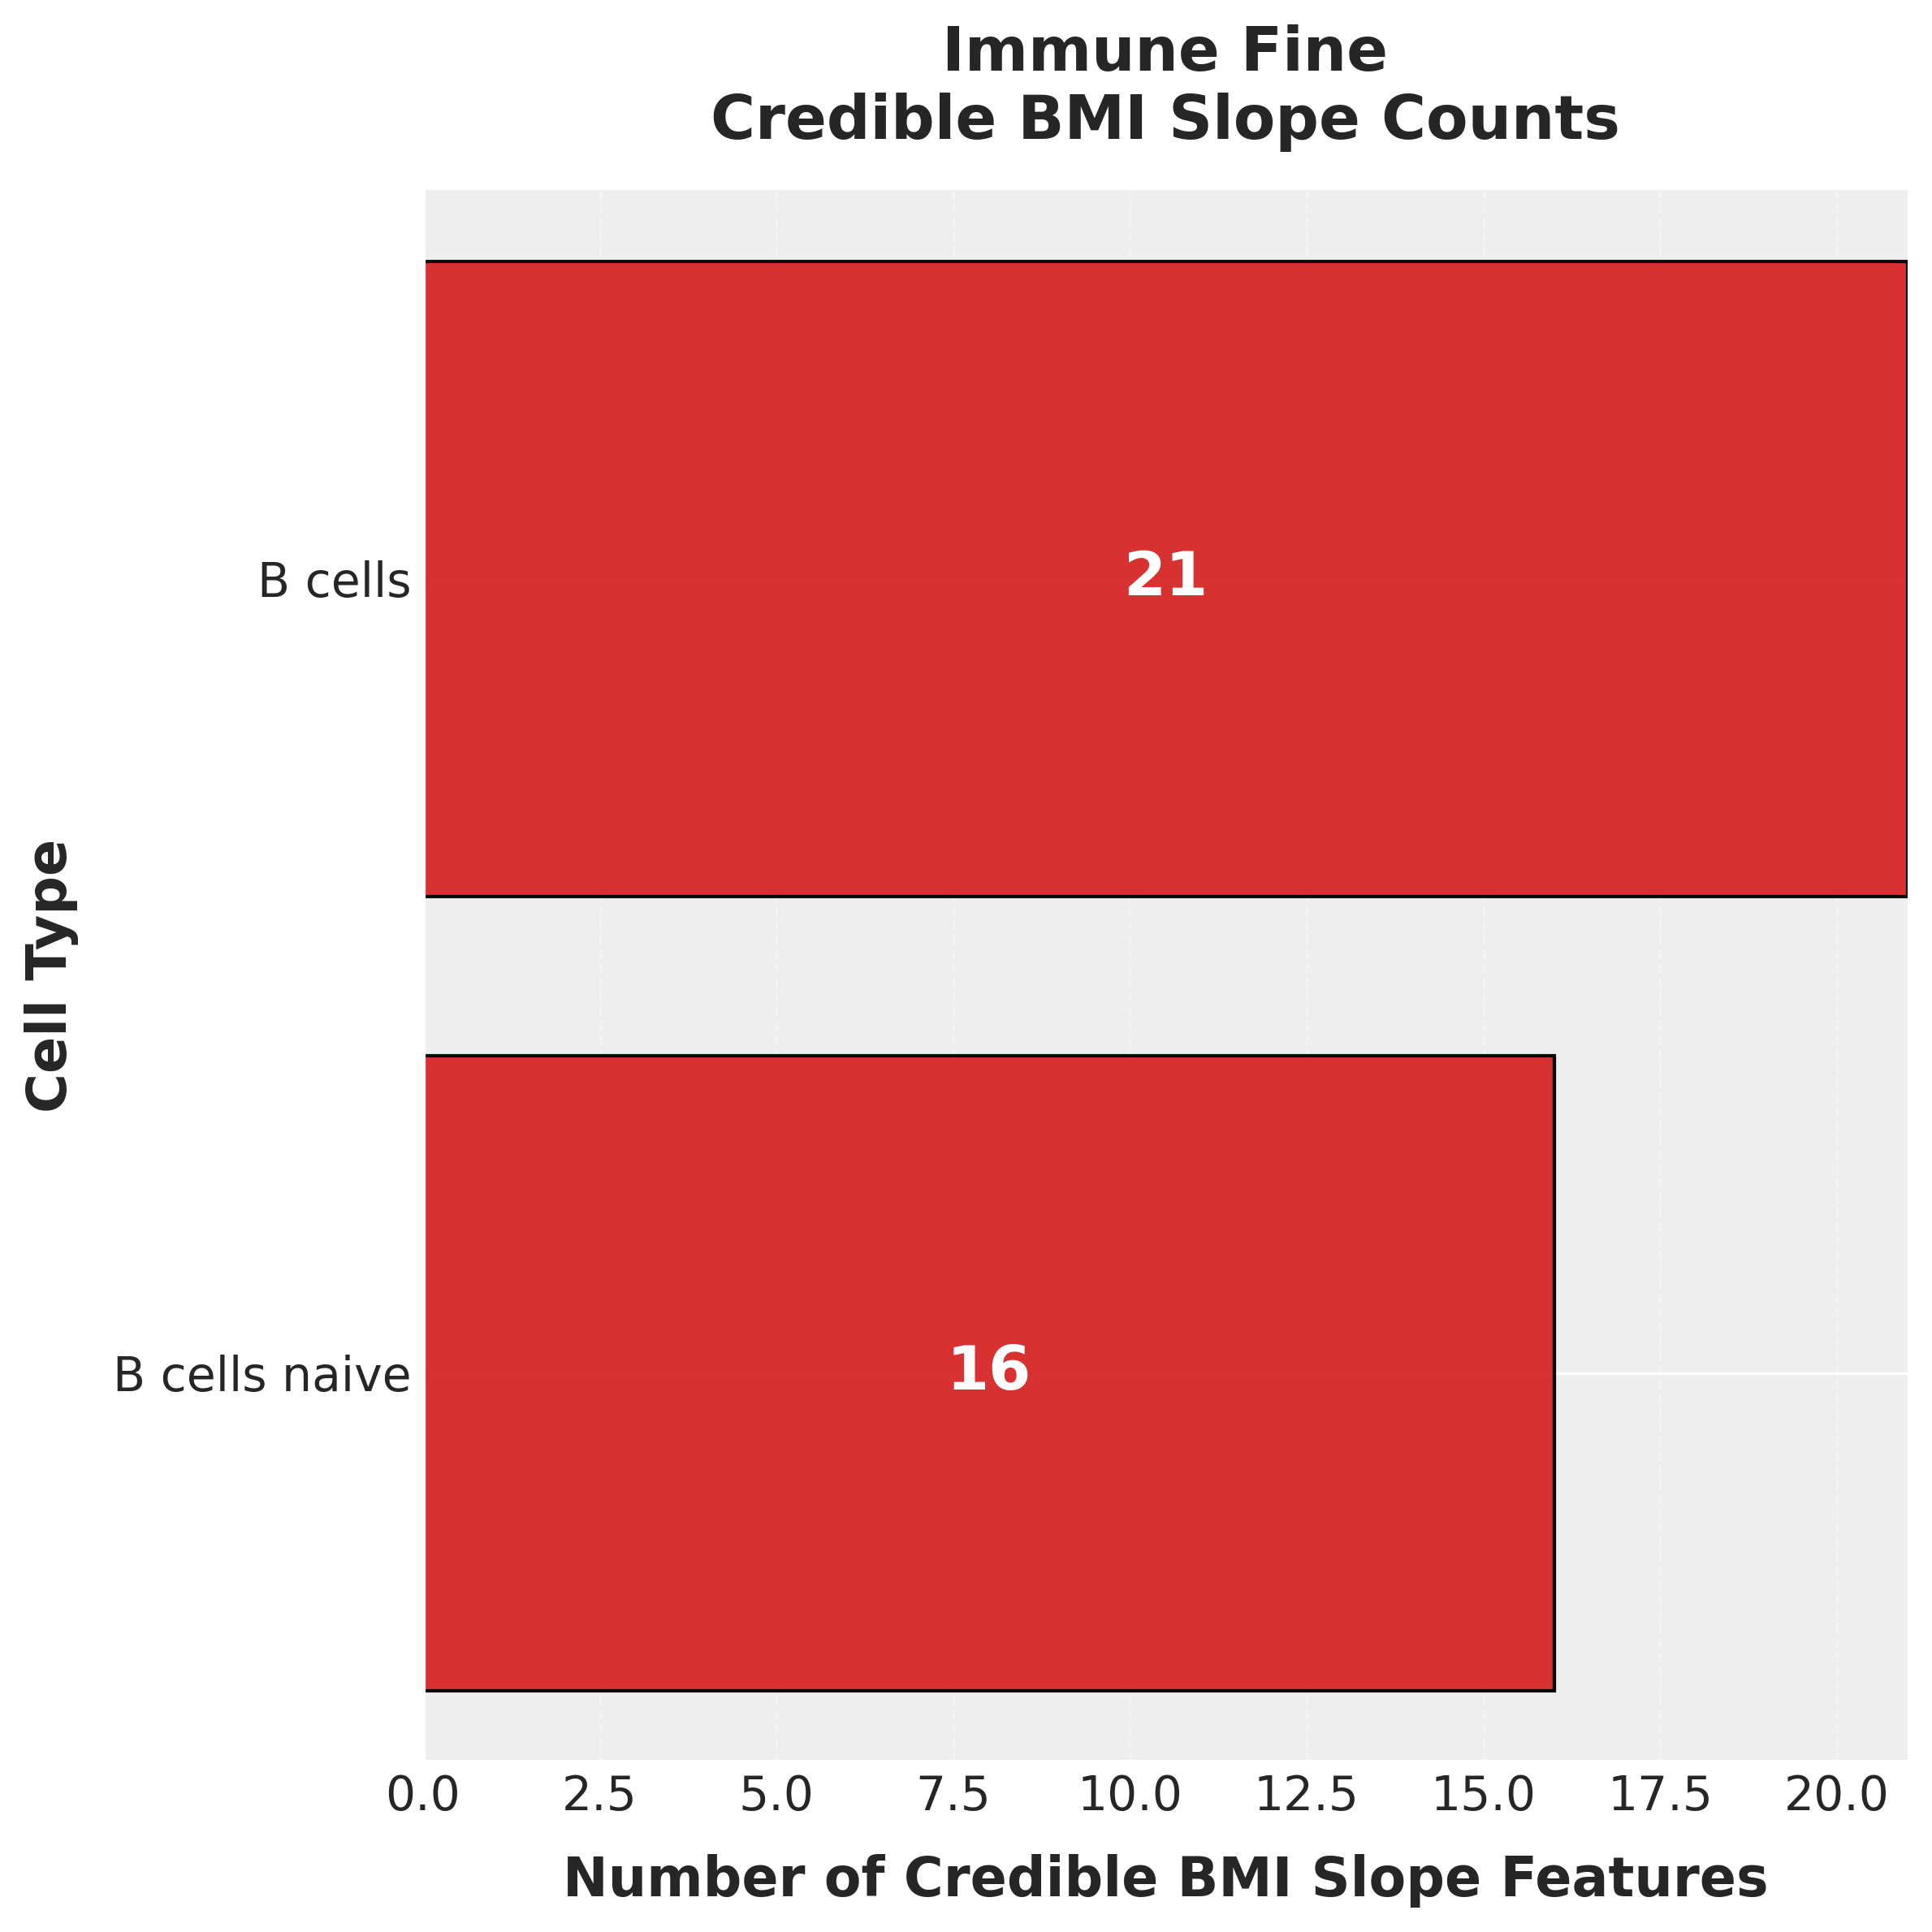

  ✅ Saved legend PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_fine/continuous_publication_figures/stacked_bar_plots/legend_bmi_slopes_Immune_Fine.png
  ✅ Saved legend SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/stacked_bar_plots/immune_fine/legend_bmi_slopes_Immune_Fine.svg


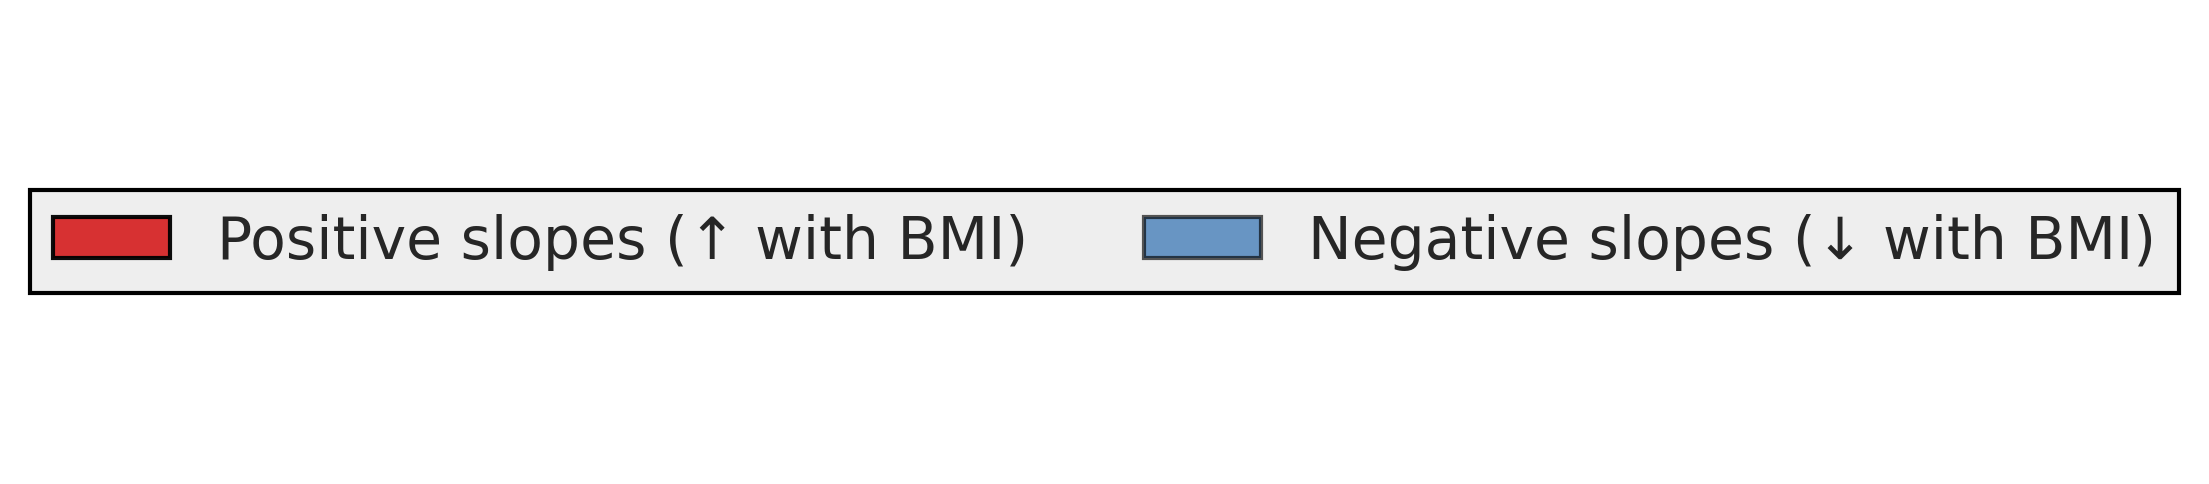

  [Immune Fine] Prepared 156 rows
    [Immune Fine] Effect size: 37 credible features
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_fine/continuous_publication_figures/stacked_bar_plots/bmi_slope_effect_size_Immune_Fine.png
  ✅ Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/stacked_bar_plots/immune_fine/bmi_slope_effect_size_Immune_Fine.svg


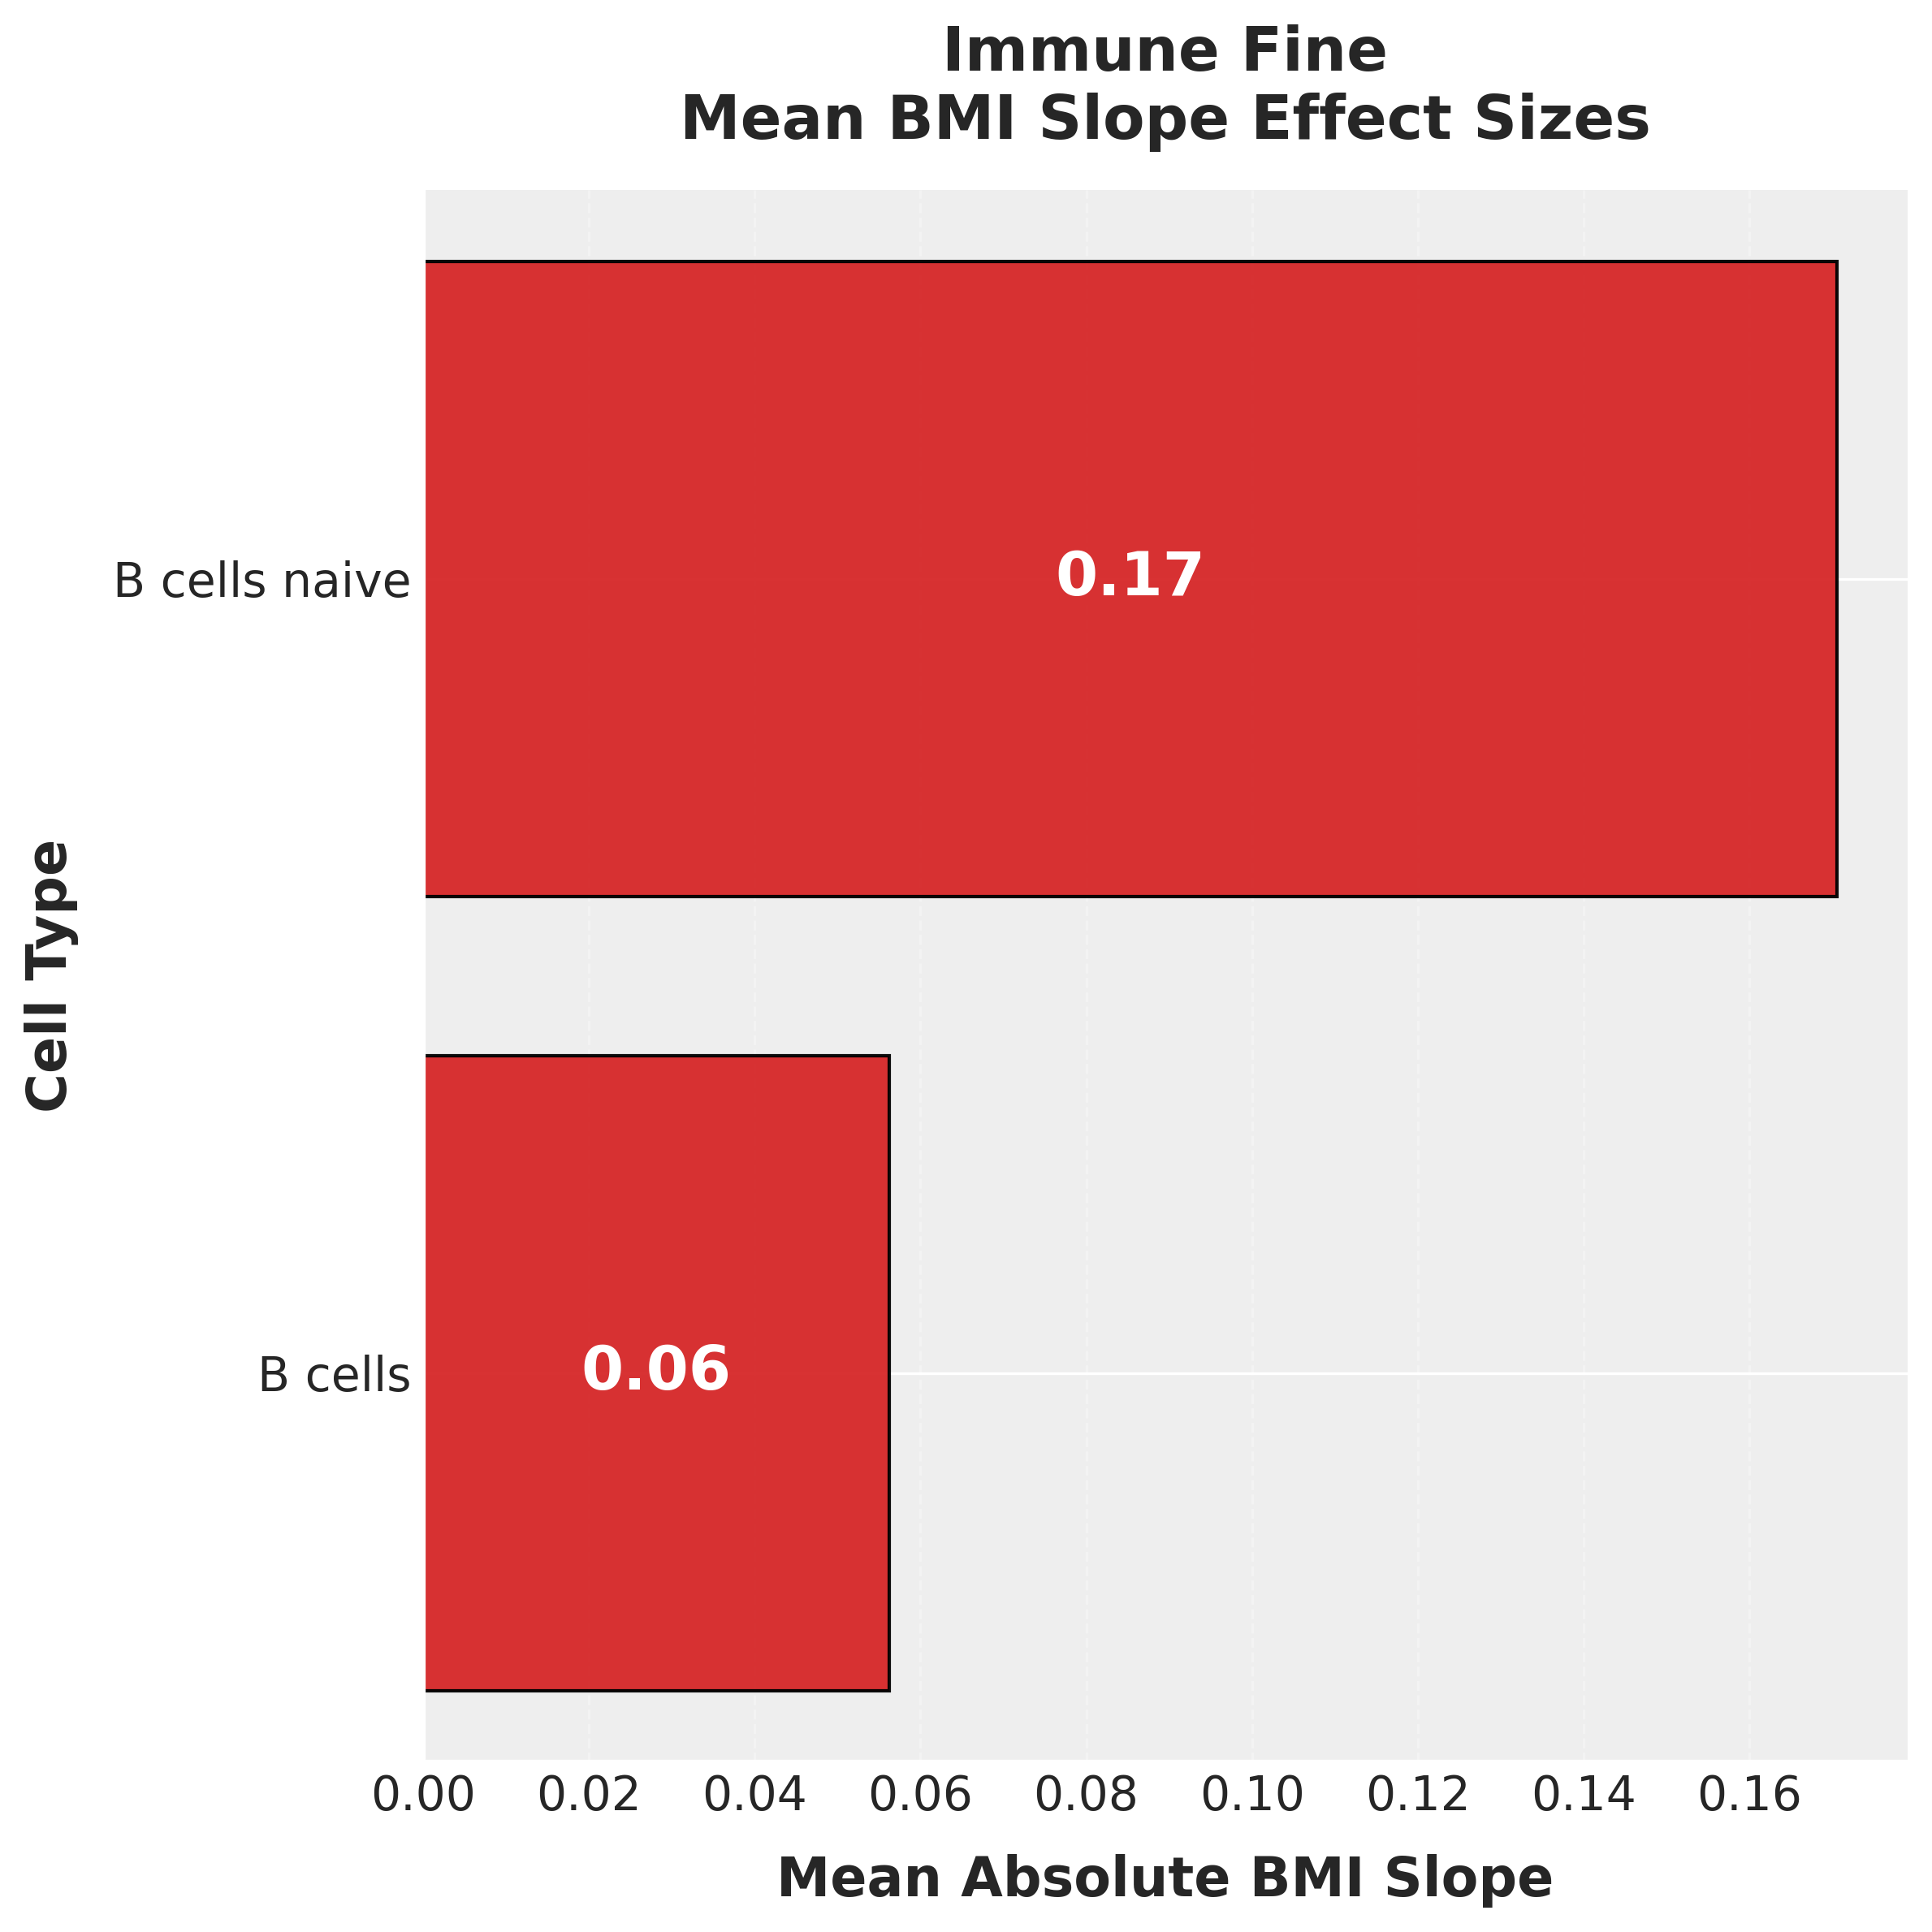


COMPARTMENT: Immune Coarse (immune_coarse)
  ✅ Loading: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_coarse/bayesian_results_continuous_with_rope.csv
  Rows loaded: 167
  [Immune Coarse] Prepared 167 rows
    [Immune Coarse] BMI slope: 42 credible features
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_coarse/continuous_publication_figures/stacked_bar_plots/bmi_slope_count_Immune_Coarse.png
  ✅ Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/stacked_bar_plots/immune_coarse/bmi_slope_count_Immune_Coarse.svg


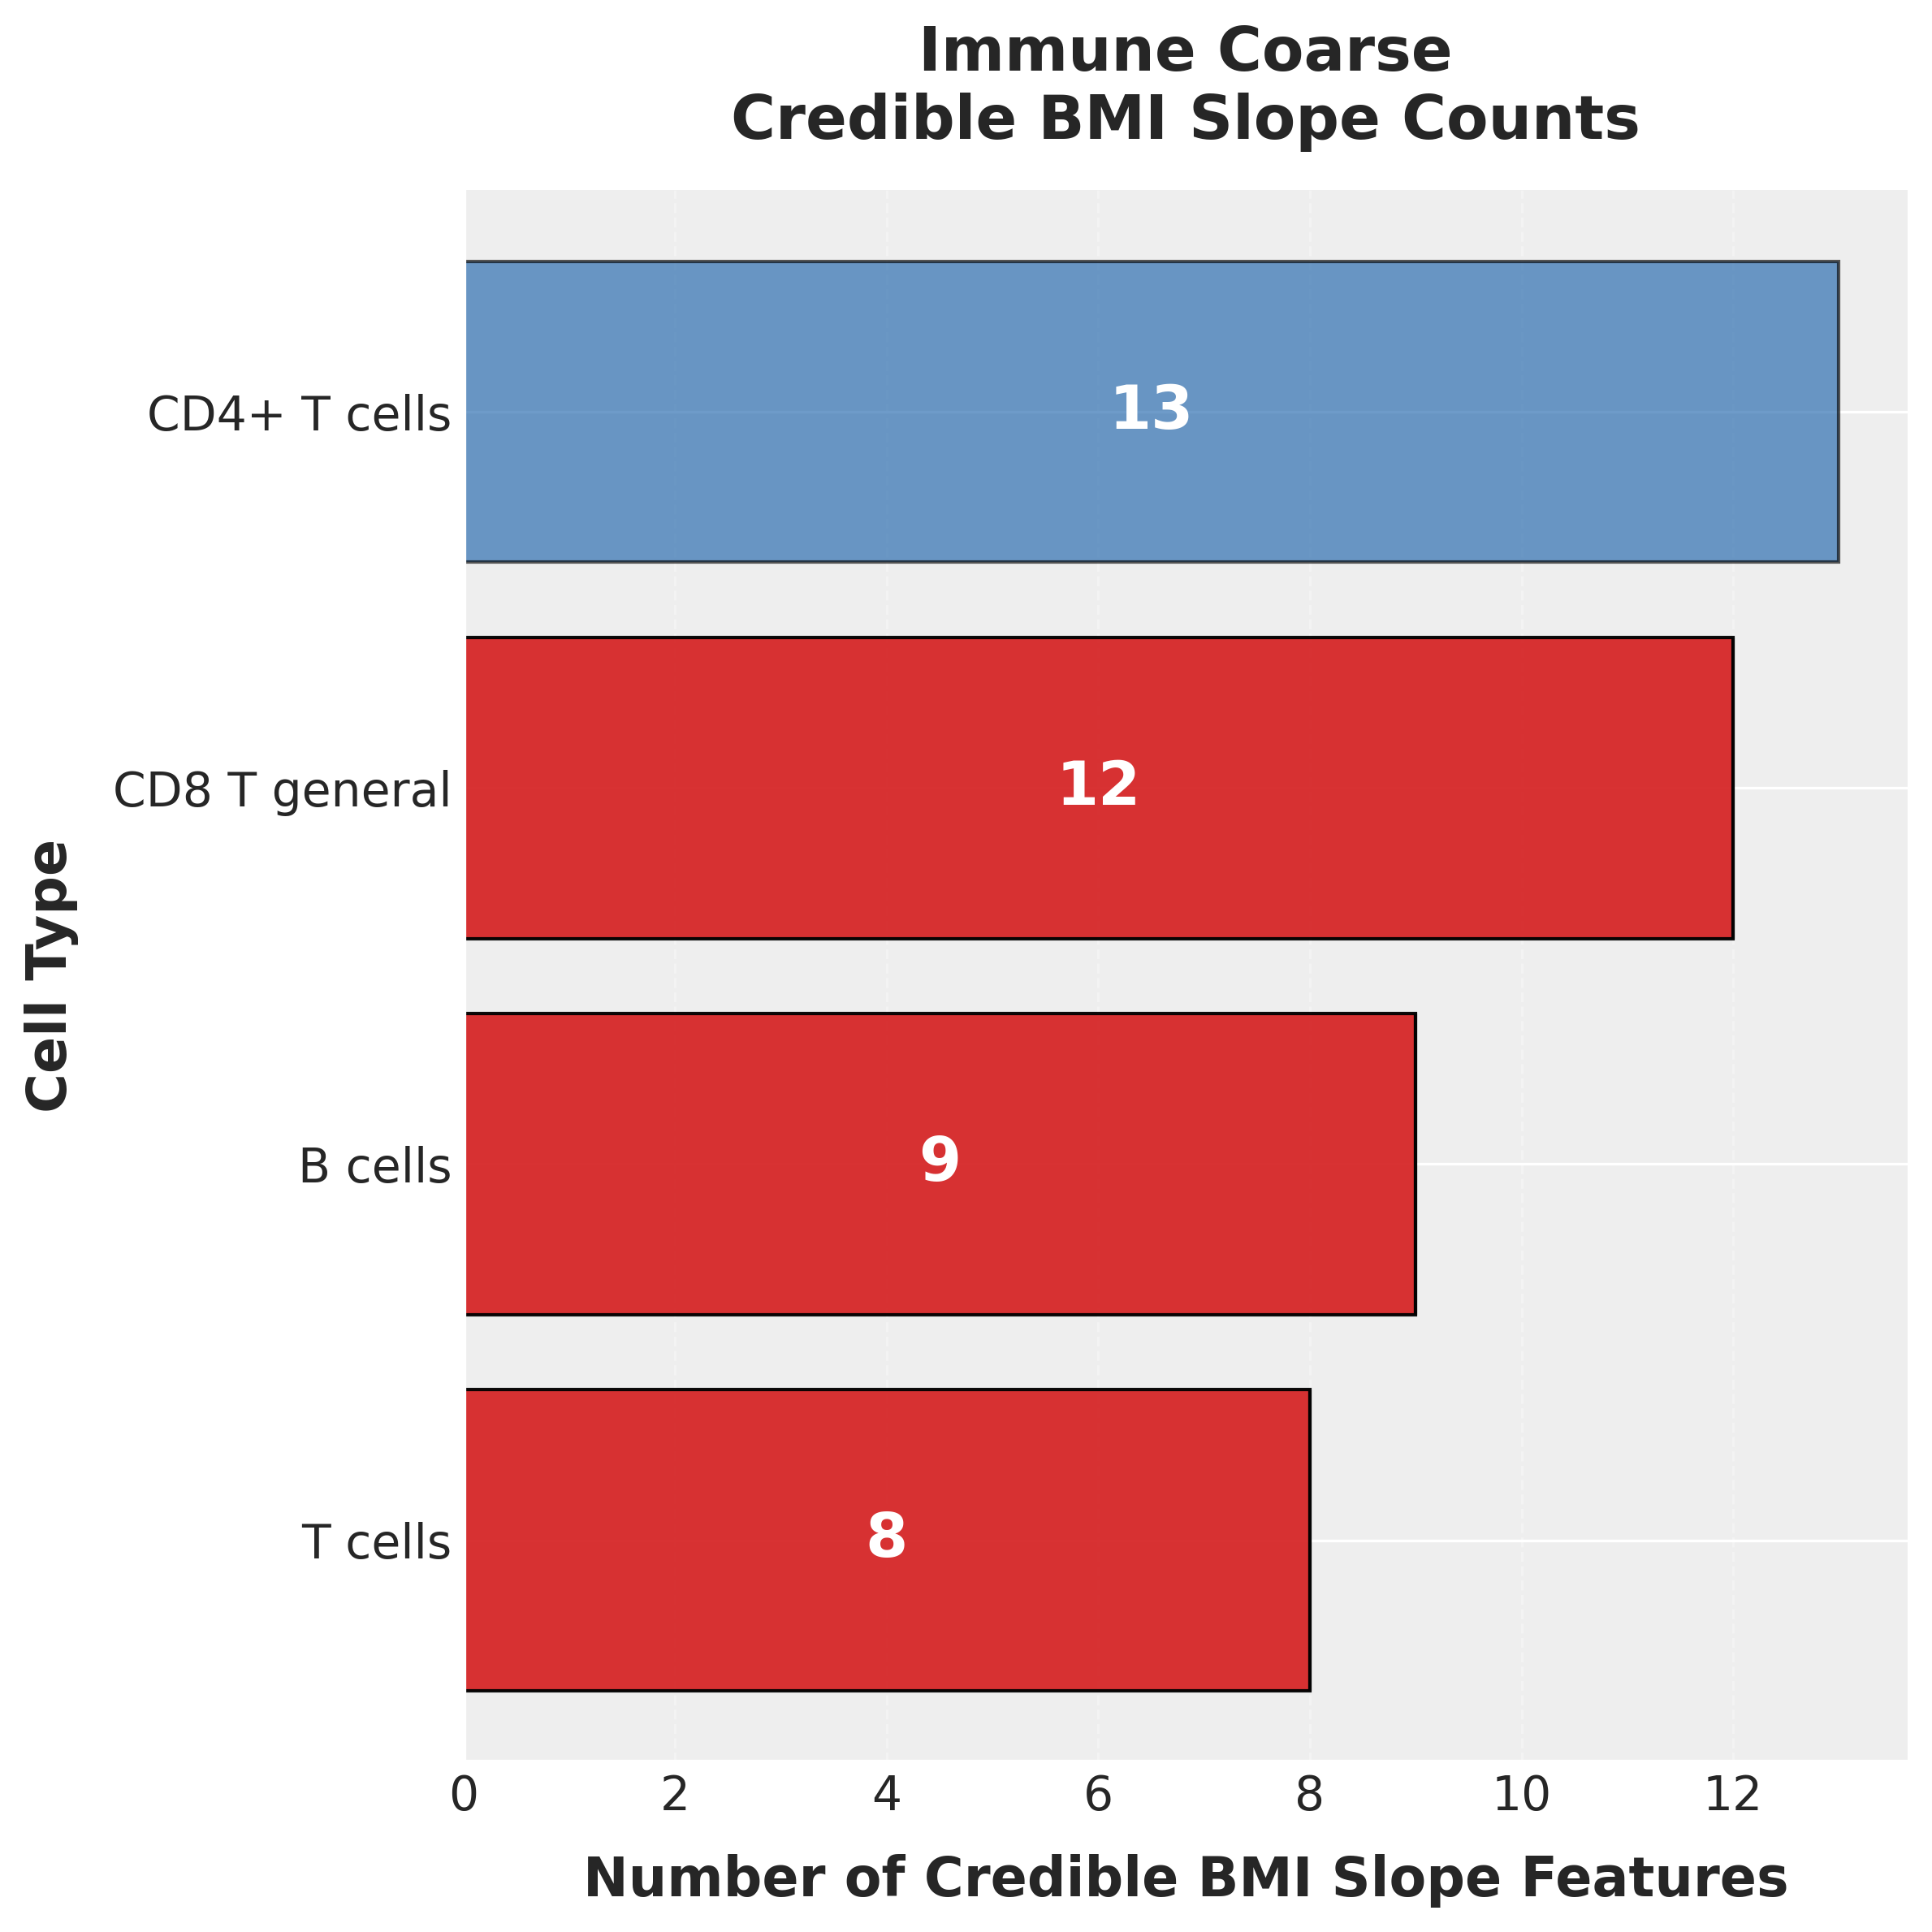

  ✅ Saved legend PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_coarse/continuous_publication_figures/stacked_bar_plots/legend_bmi_slopes_Immune_Coarse.png
  ✅ Saved legend SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/stacked_bar_plots/immune_coarse/legend_bmi_slopes_Immune_Coarse.svg


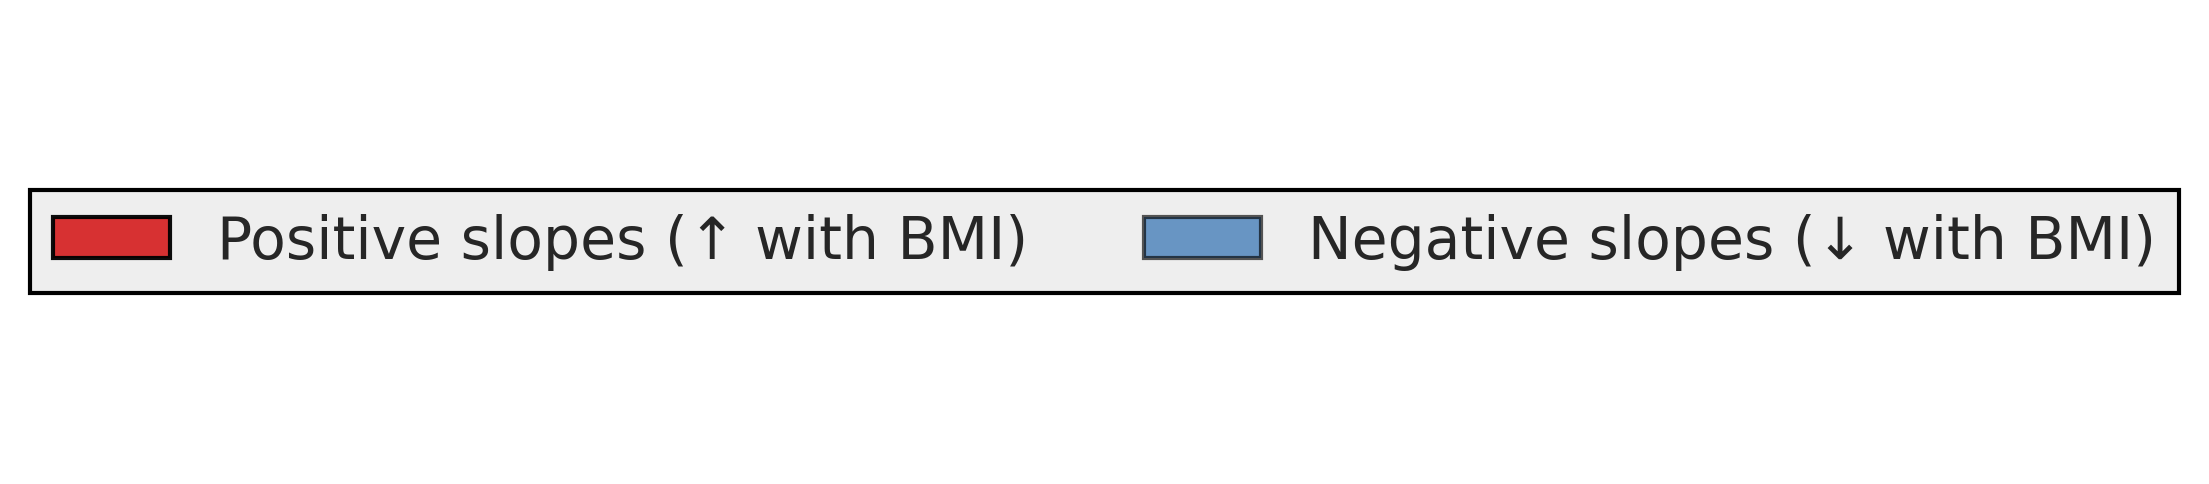

  [Immune Coarse] Prepared 167 rows
    [Immune Coarse] Effect size: 42 credible features
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_continuous_immune_coarse/continuous_publication_figures/stacked_bar_plots/bmi_slope_effect_size_Immune_Coarse.png
  ✅ Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/stacked_bar_plots/immune_coarse/bmi_slope_effect_size_Immune_Coarse.svg


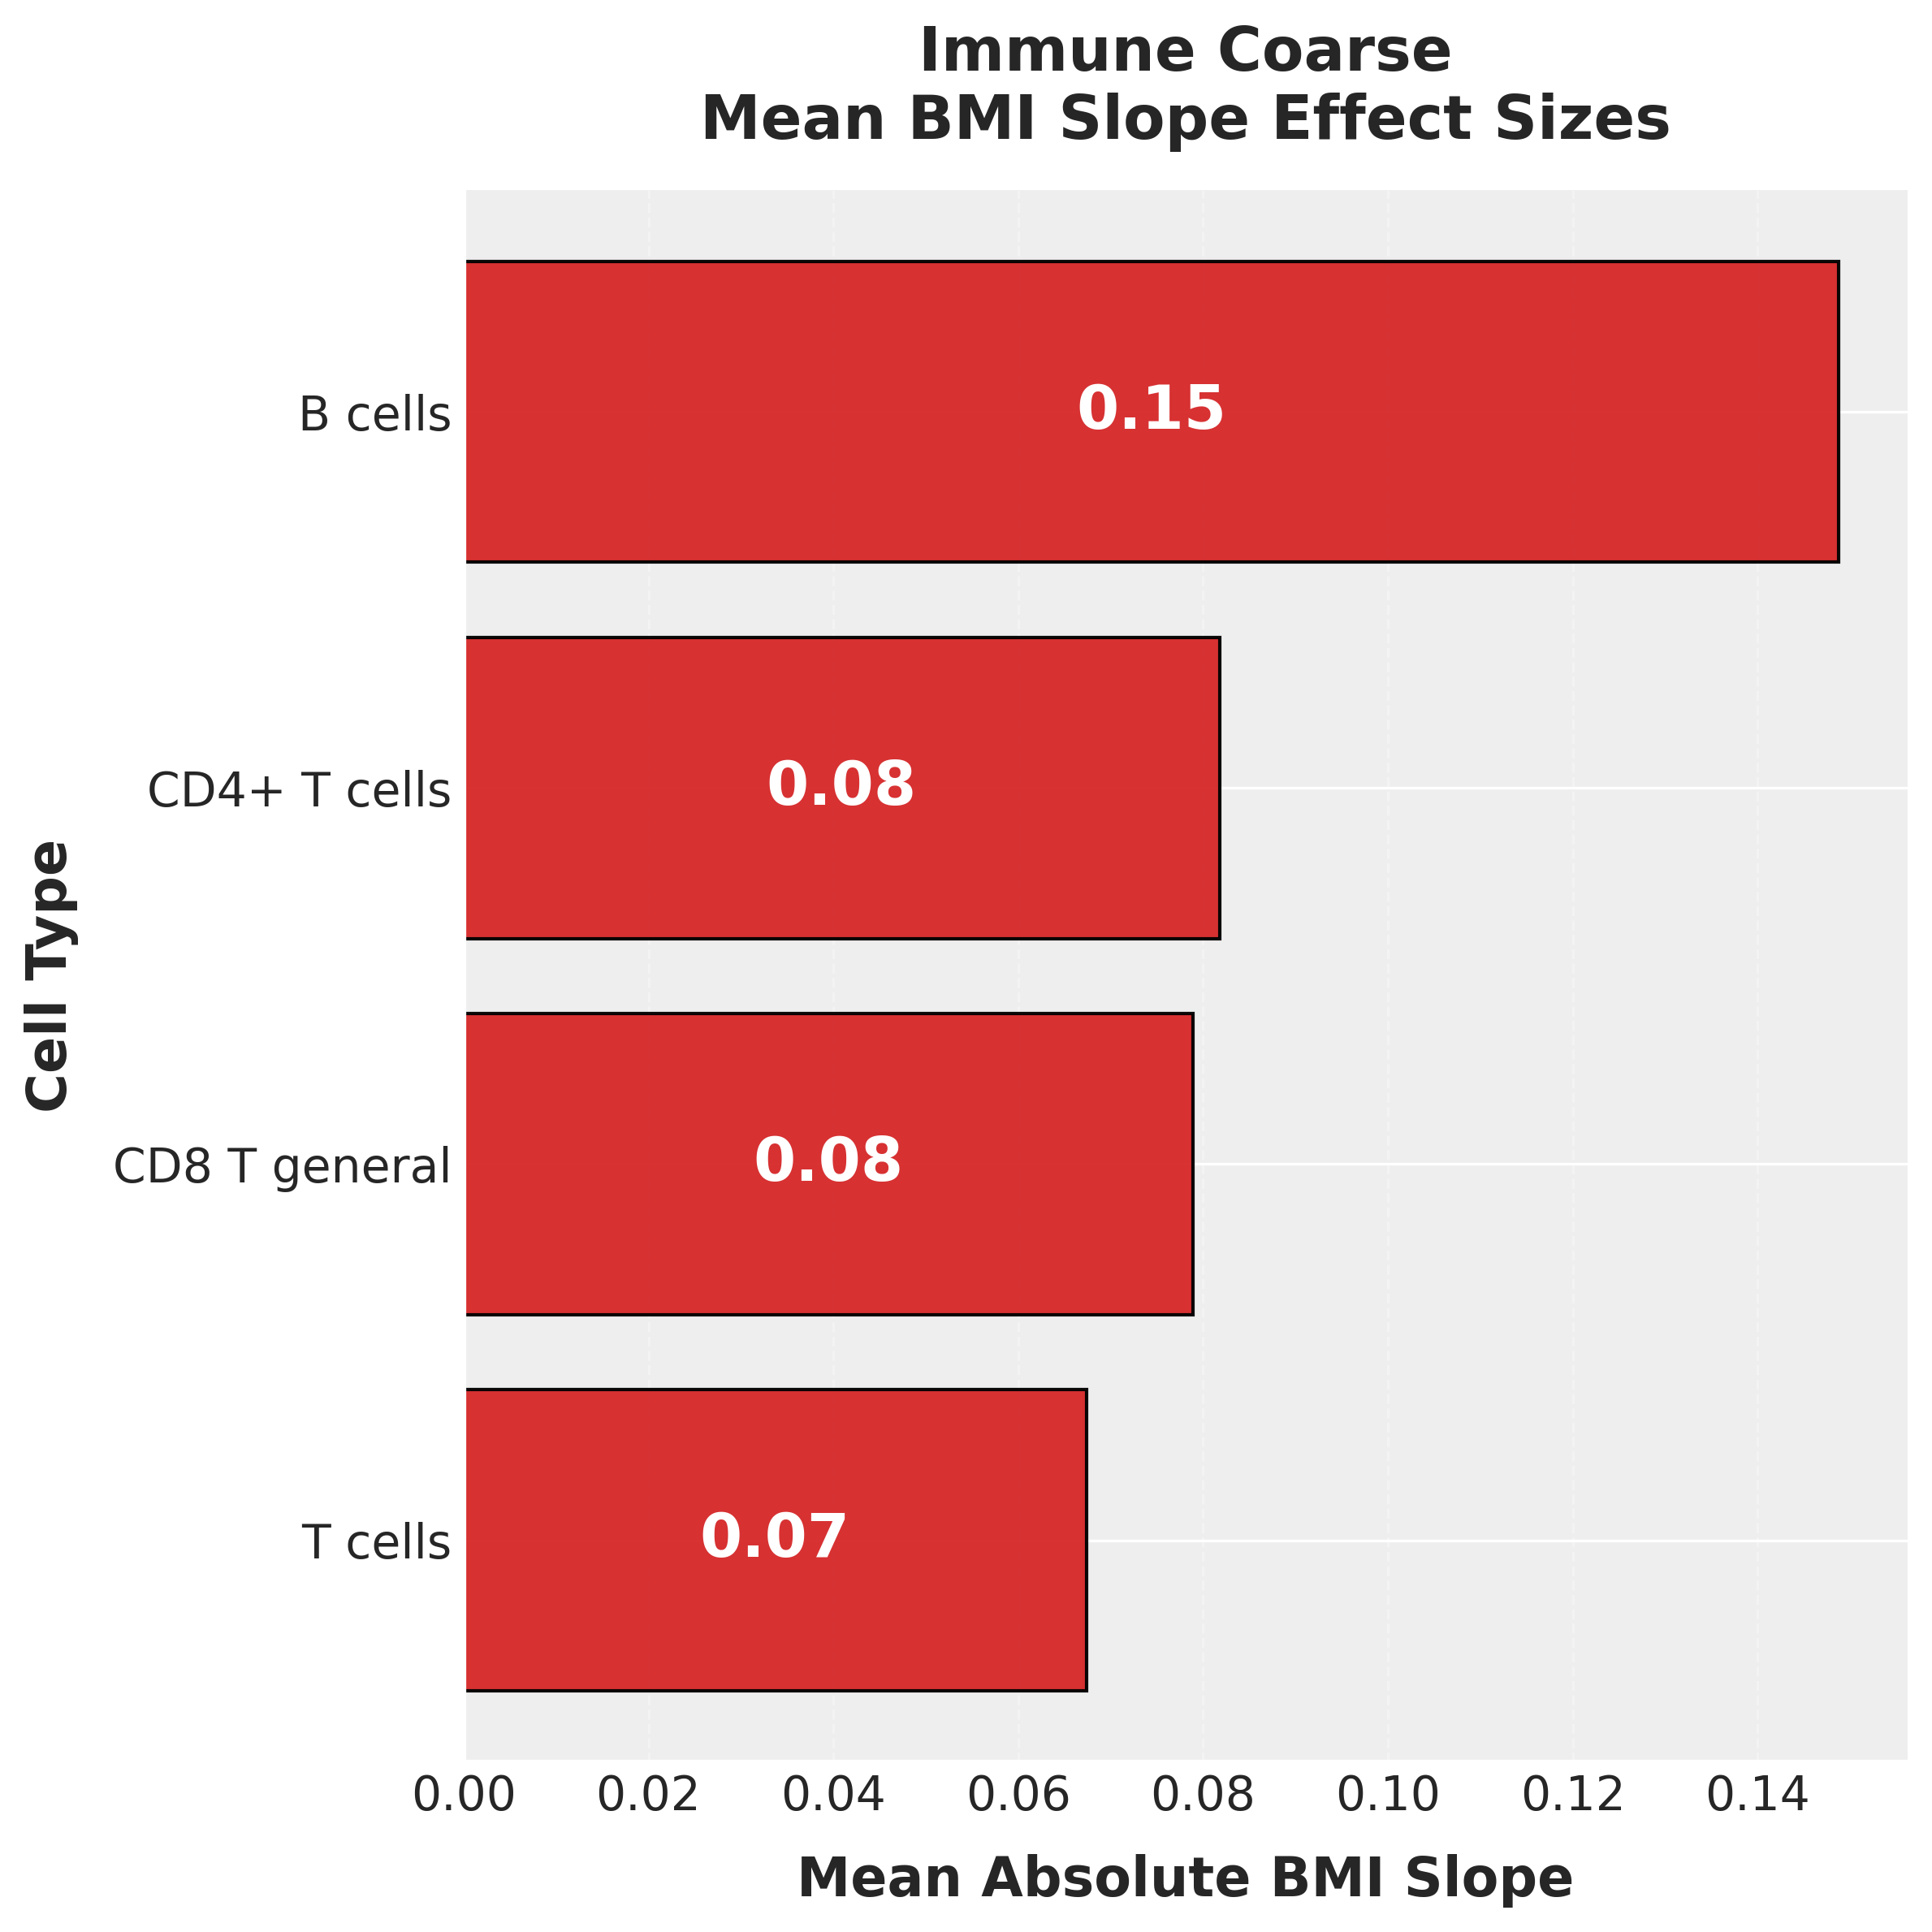


COMBINED PLOTS
  [All_Compartments] Prepared 572 rows
    [All_Compartments] BMI slope: 183 credible features
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/continuous_publication_figures/stacked_bar_plots/combined/bmi_slope_count_All_Compartments.png
  ✅ Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/stacked_bar_plots/combined/bmi_slope_count_All_Compartments.svg


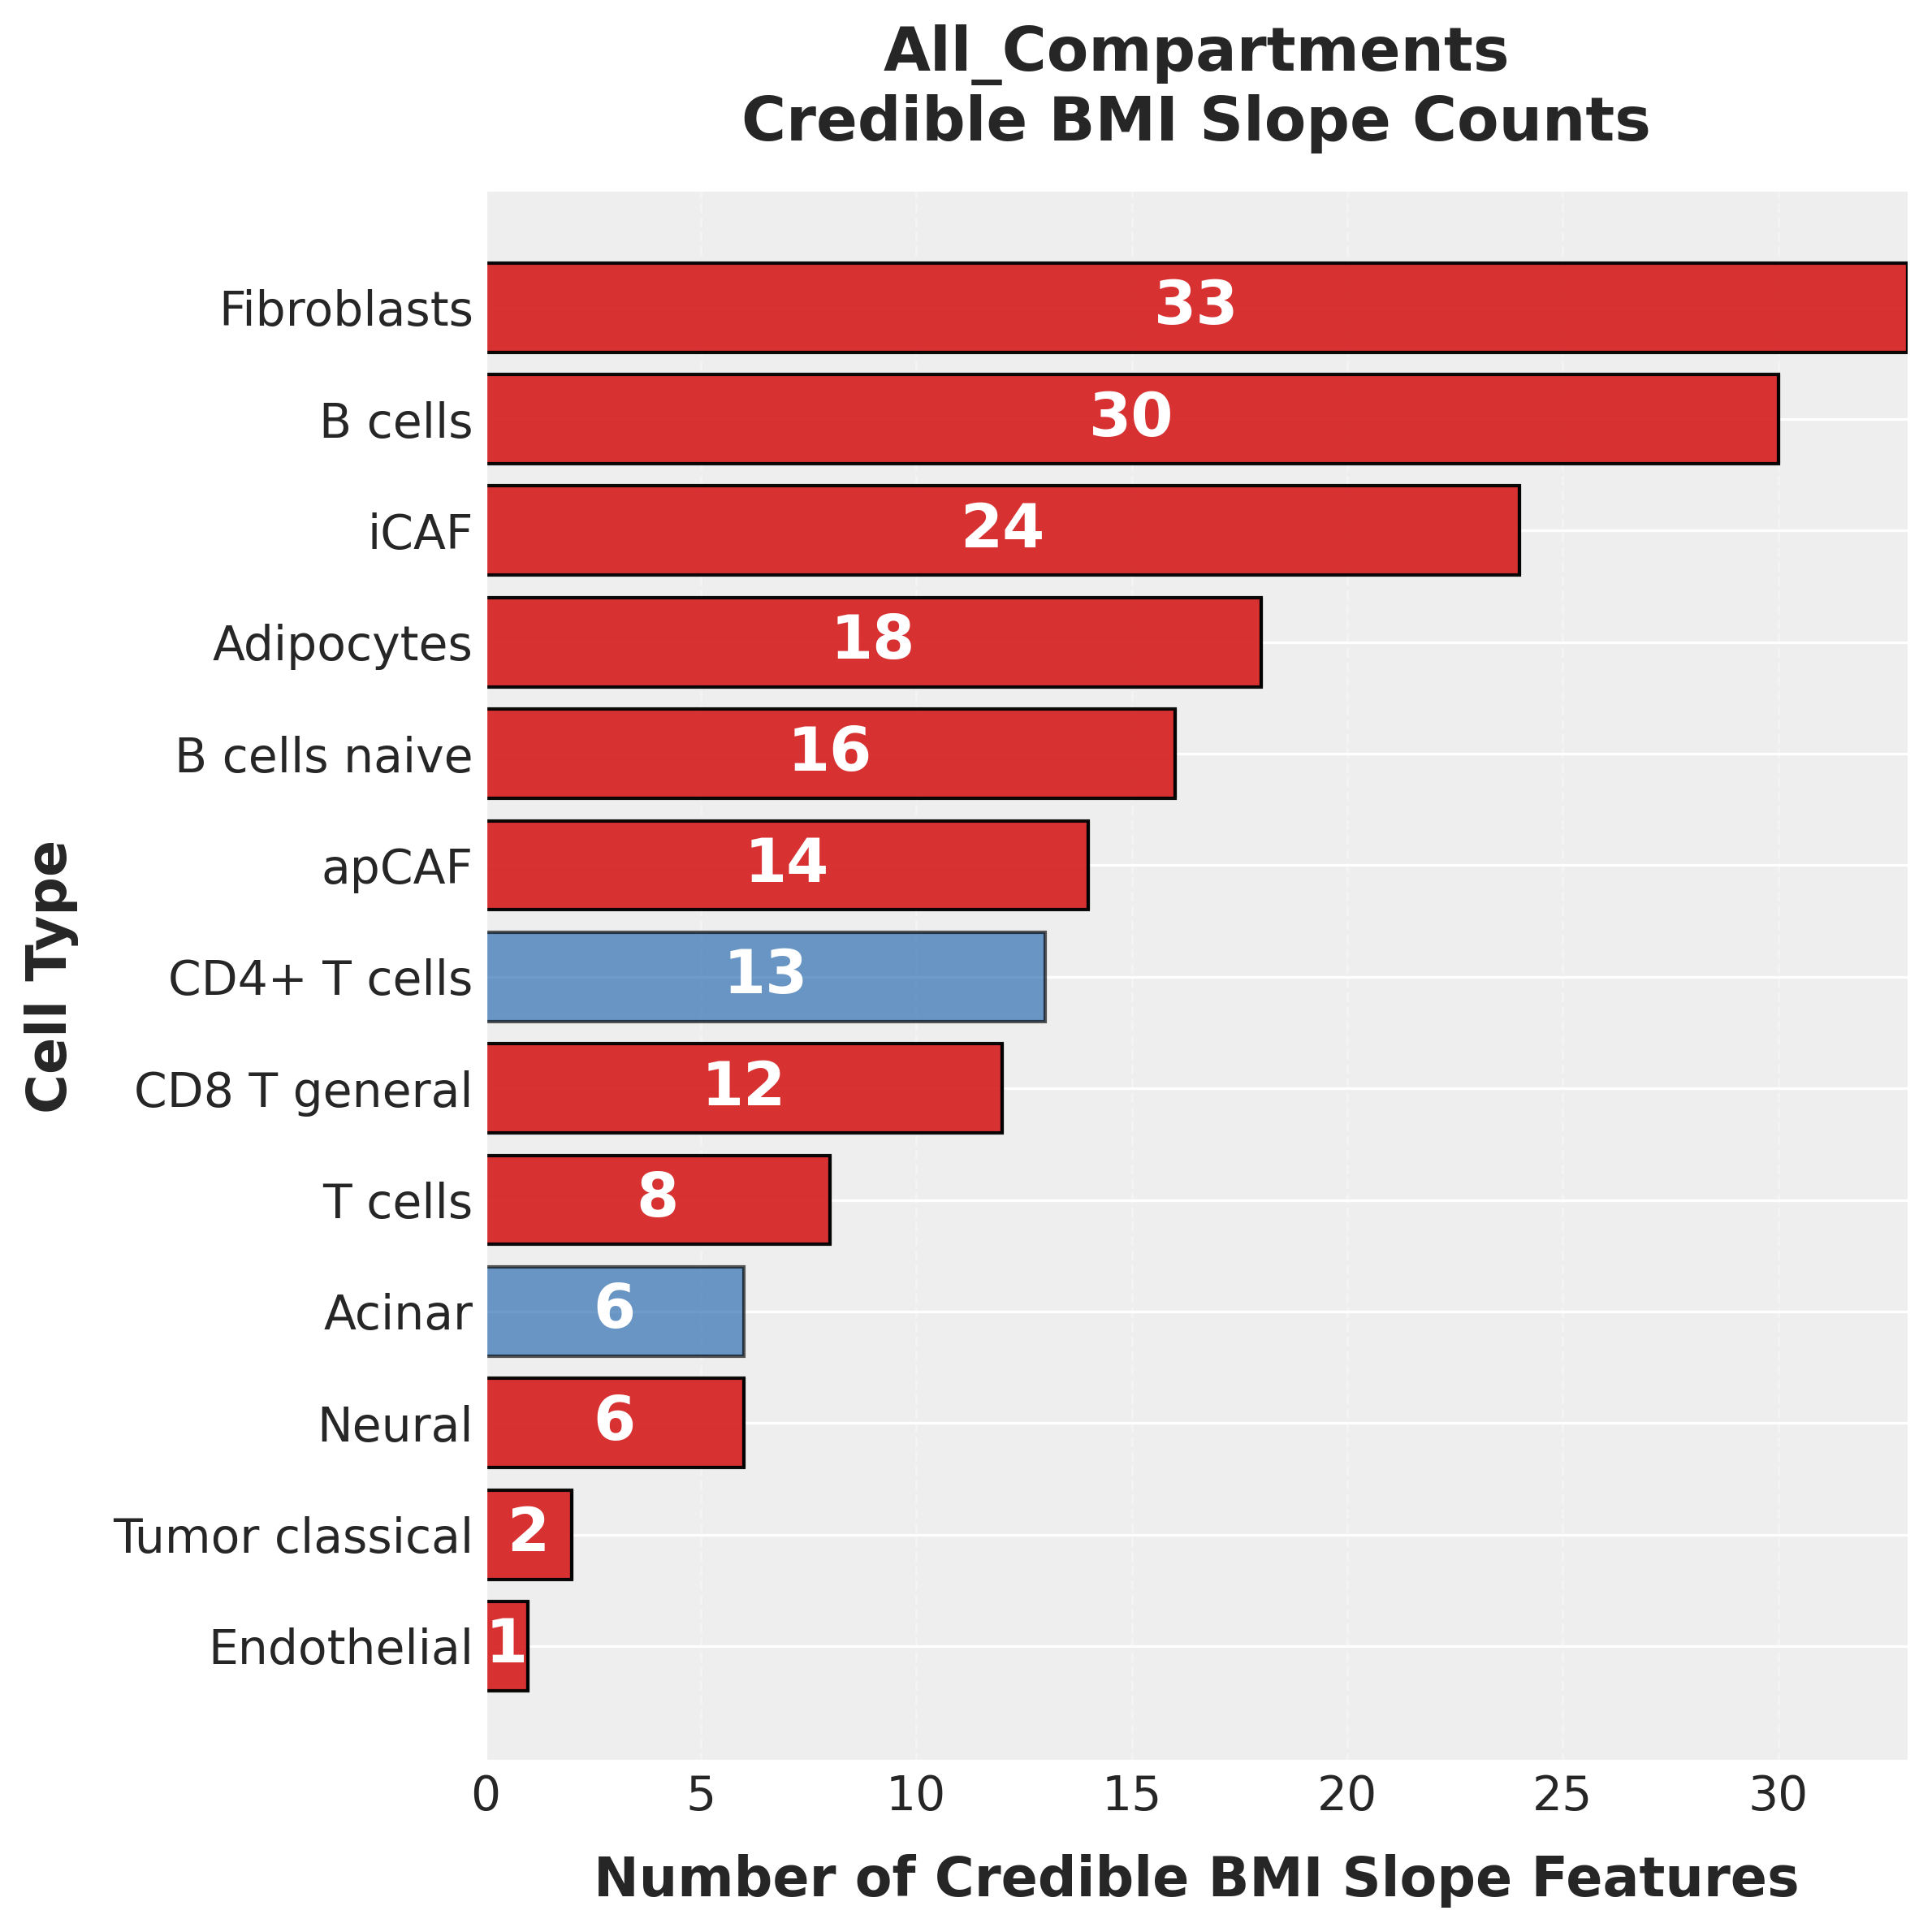

  ✅ Saved legend PNG: /content/drive/MyDrive/new_dysfunction/continuous_publication_figures/stacked_bar_plots/combined/legend_bmi_slopes_All_Compartments.png
  ✅ Saved legend SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/stacked_bar_plots/combined/legend_bmi_slopes_All_Compartments.svg


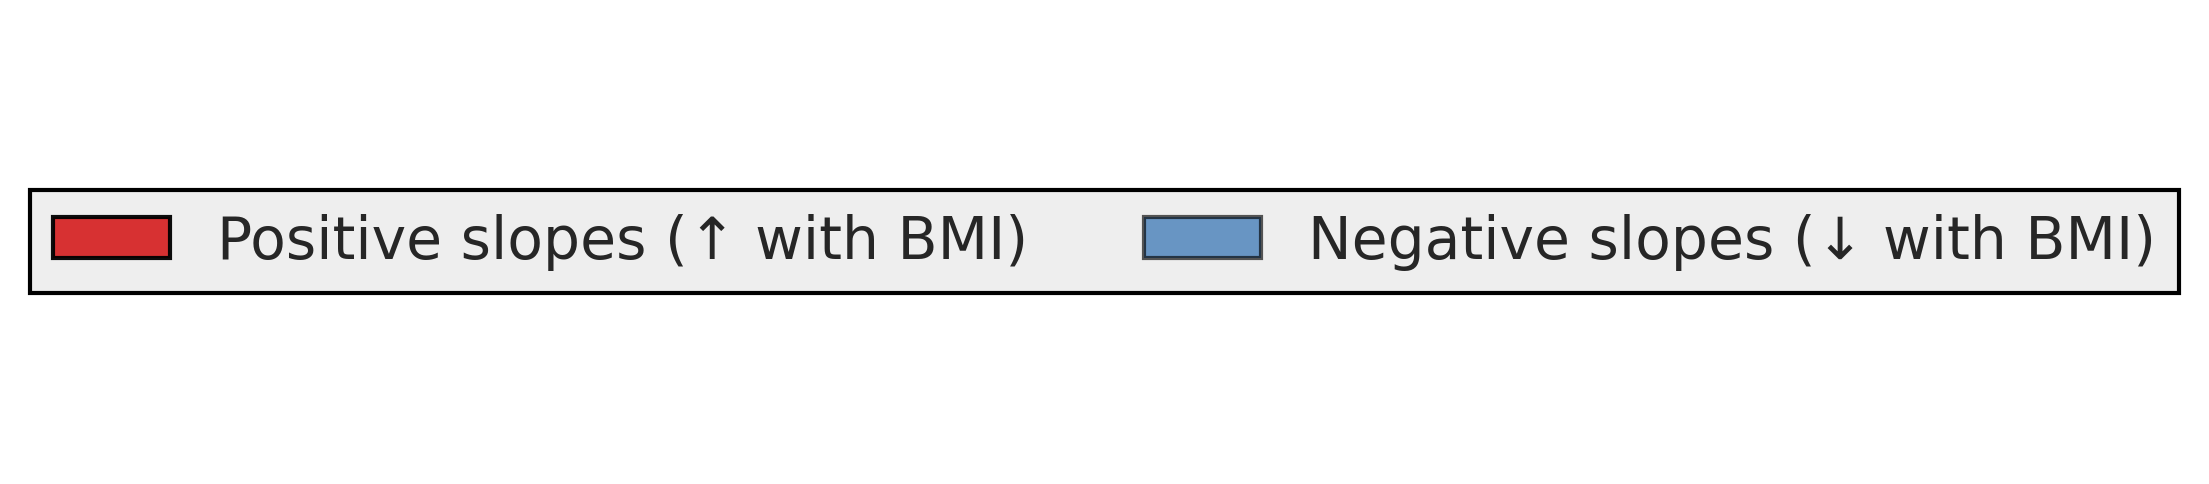

  [All_Compartments] Prepared 572 rows
    [All_Compartments] Effect size: 183 credible features
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/svg_continuous/stacked_bar_plots/combined/bmi_slope_effect_size_All_Compartments.png
  ✅ Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_continuous/stacked_bar_plots/combined/bmi_slope_effect_size_All_Compartments.svg


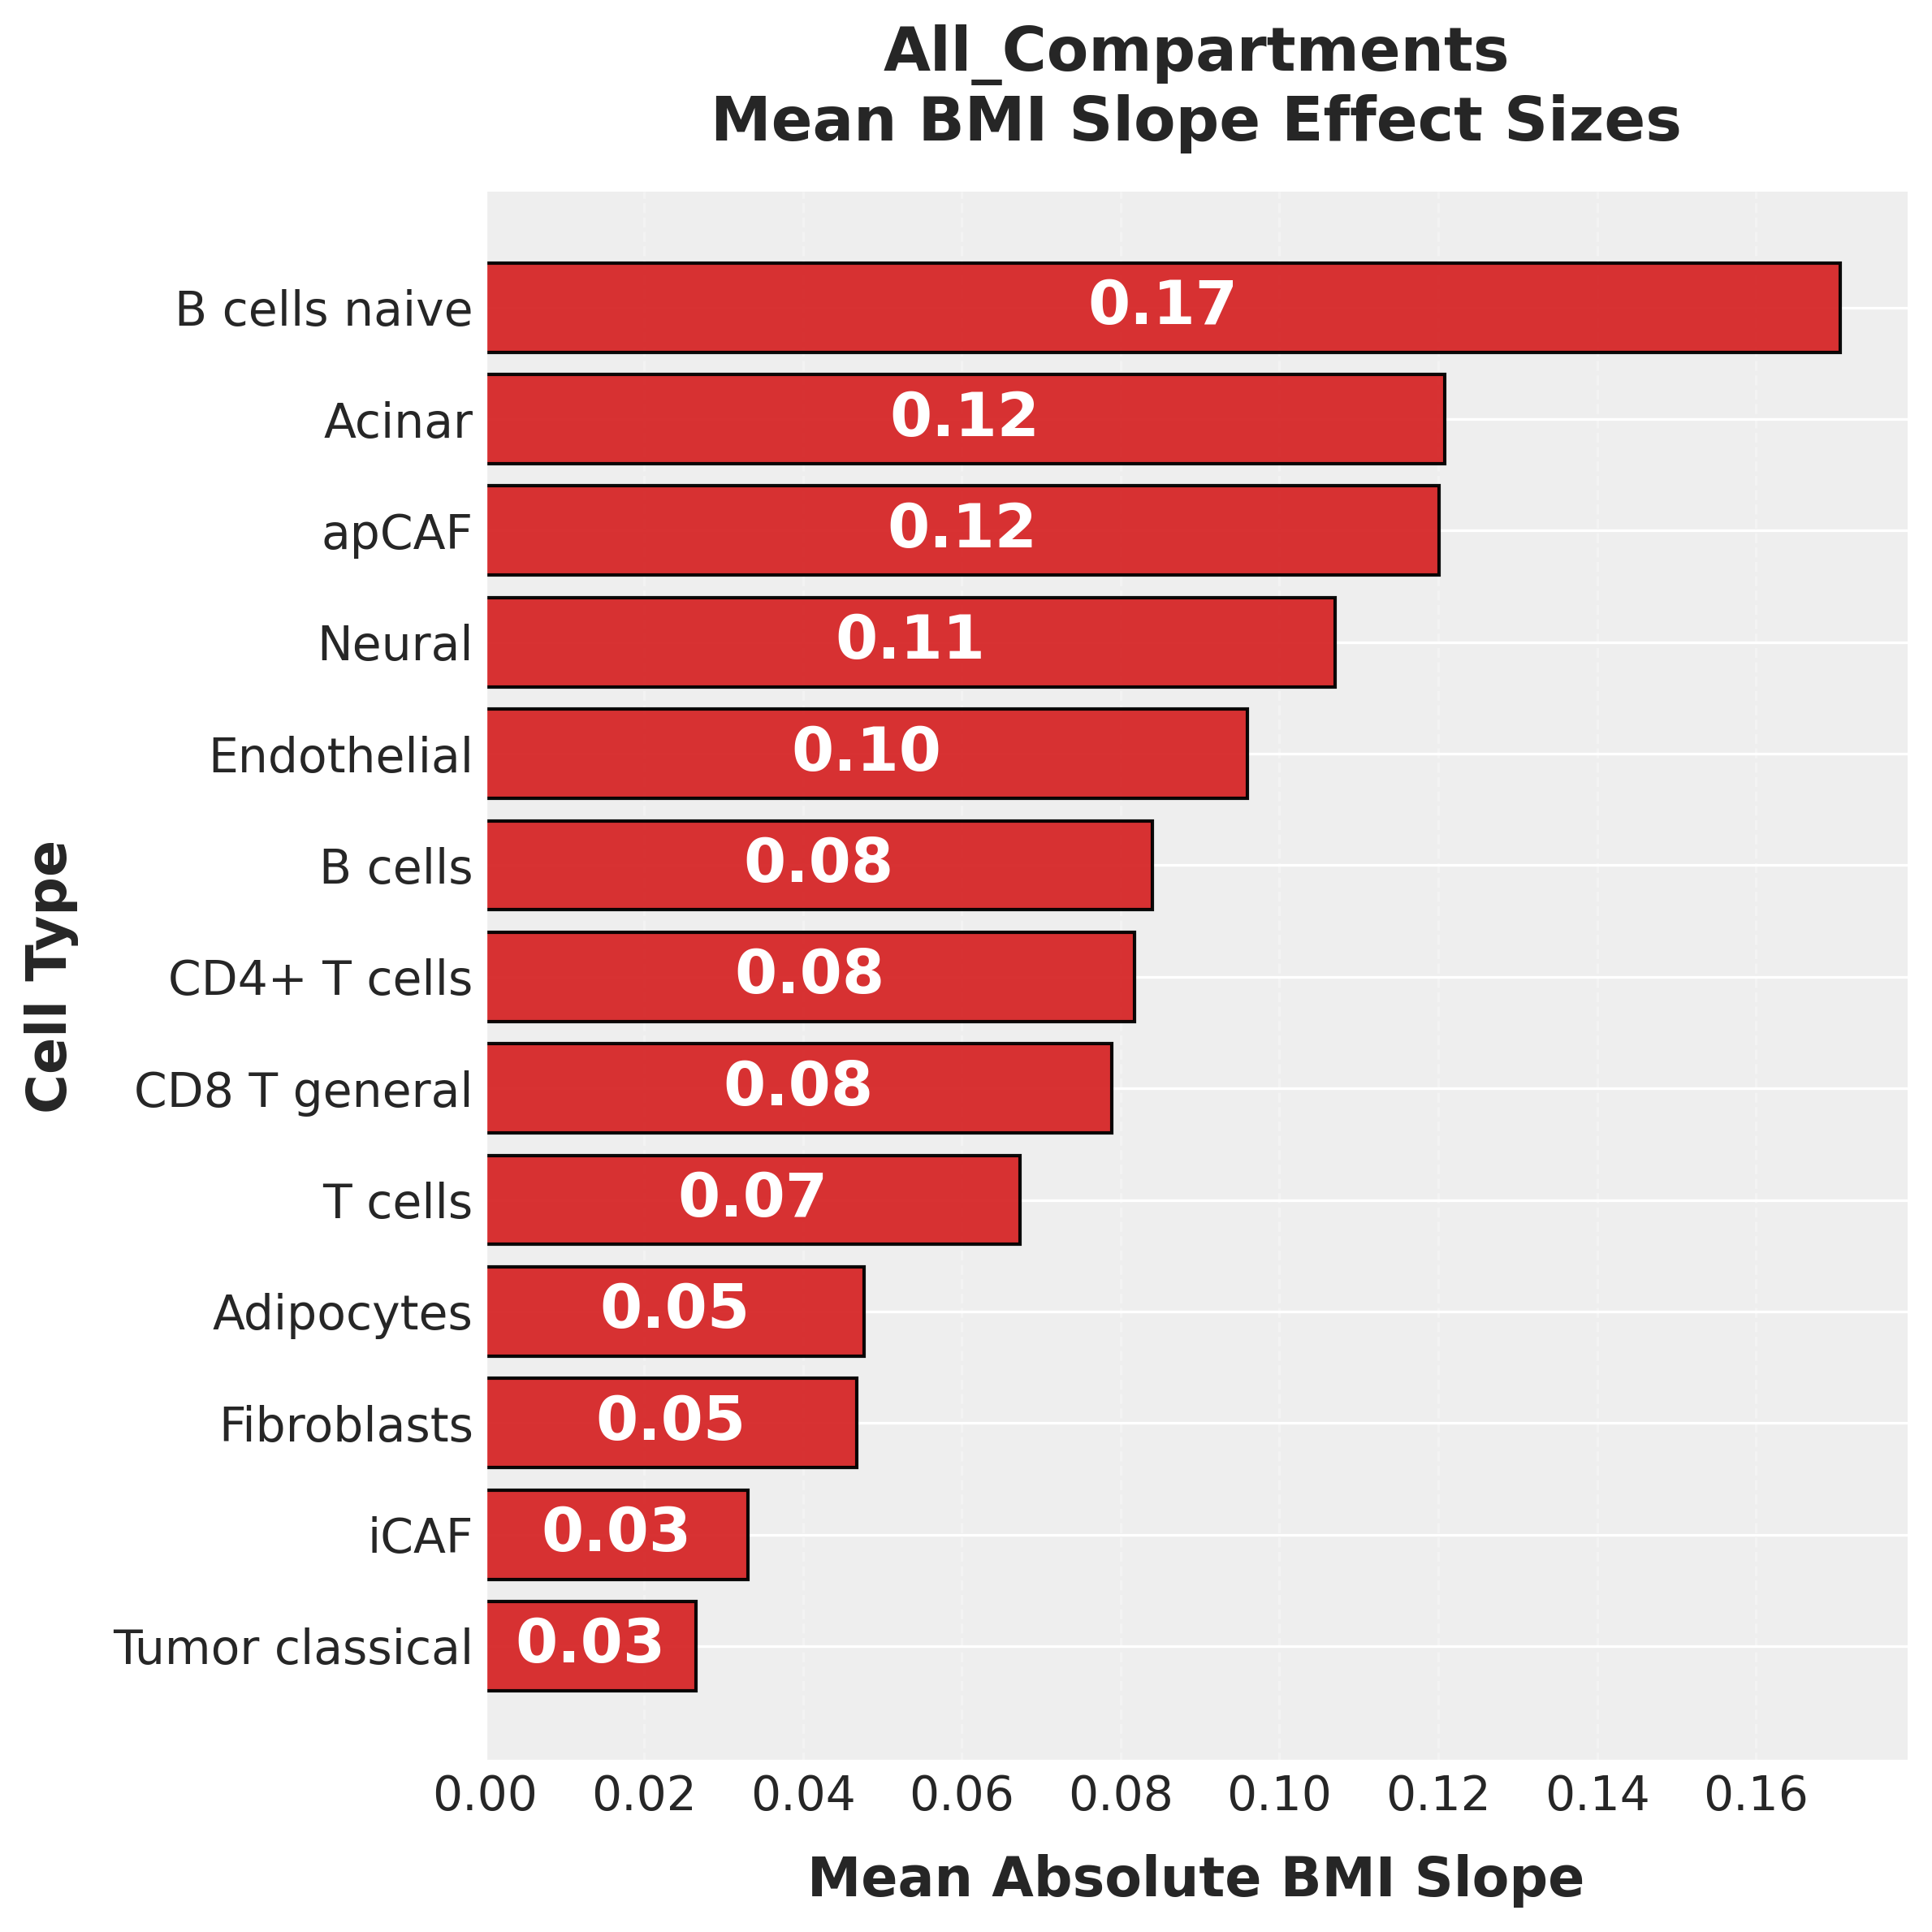


✅ COMPLETED


In [ ]:
#!/usr/bin/env python3
"""
Stacked Bar Plots for Continuous BMI Model
Shows credible BMI slope counts with separate legend.
"""

import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ============================================================================
# CONFIGURATION & TUNABLES
# ============================================================================

BASE = "/content/drive/MyDrive/new_dysfunction"

COMPARTMENTS = {
    'nonimmune': {
        'dir': f"{BASE}/bayesian_hierarchical_continuous_nonimmune",
        'name': 'Non-Immune'
    },
    'immune_fine': {
        'dir': f"{BASE}/bayesian_hierarchical_continuous_immune_fine",
        'name': 'Immune Fine'
    },
    'immune_coarse': {
        'dir': f"{BASE}/bayesian_hierarchical_continuous_immune_coarse",
        'name': 'Immune Coarse'
    }
}

SVG_BASE = f"{BASE}/svg_continuous"
SVG_SUBFOLDER = "stacked_bar_plots"

# Output Configuration
MAKE_COMBINED = True
SAVE_DATA_TABLE = True
SPLIT_BY_DIRECTION = True

# Figure Dimensions
FIGURE_WIDTH = 8
FIGURE_HEIGHT = 8
FIGURE_DPI = 300

# Bar Plot Aesthetics
BAR_WIDTH = 0.8
BAR_ALPHA_POSITIVE = 0.95
BAR_ALPHA_NEGATIVE = 0.65
BAR_EDGE_LINEWIDTH = 1
BAR_EDGE_COLOR = 'black'

# Font Sizes
FONT_SIZE_BASE = 9
FONT_SIZE_TITLE = 18
FONT_SIZE_LABEL = 16
FONT_SIZE_TICK = 14
FONT_SIZE_BAR_TEXT = 18
FONT_SIZE_LEGEND = 14

# Axes & Grid Styling
AXES_LINEWIDTH = 1.5
GRID_ALPHA = 0.3
GRID_LINESTYLE = '--'
GRID_AXIS = 'x'

# Spacing & Padding
TITLE_PAD = 15
LABEL_PAD = 10
FIGURE_TIGHT_LAYOUT = True

# Colors - Blue (negative) and Red (positive)
COLOR_POSITIVE = "#D62728"  # Red for positive slopes
COLOR_NEGATIVE = "#2166AC"  # Blue for negative slopes

# Value Label Configuration
VALUE_LABEL_COLOR = 'white'
VALUE_LABEL_WEIGHT = 'bold'
VALUE_LABEL_HA = 'center'
VALUE_LABEL_VA = 'center'
COUNT_LABEL_THRESHOLD = 0

# Spine Configuration
SHOW_TOP_SPINE = False
SHOW_RIGHT_SPINE = False
SHOW_LEFT_SPINE = True
SHOW_BOTTOM_SPINE = True

plt.rcParams.update({
    "figure.dpi": FIGURE_DPI,
    "savefig.dpi": FIGURE_DPI,
    "font.size": FONT_SIZE_BASE,
    "font.family": "DejaVu Sans",
    "axes.titlesize": FONT_SIZE_TITLE,
    "axes.labelsize": FONT_SIZE_LABEL,
    "xtick.labelsize": FONT_SIZE_TICK,
    "ytick.labelsize": FONT_SIZE_TICK,
    "axes.linewidth": AXES_LINEWIDTH,
})

# ============================================================================
# CELL TYPE CANONICALIZATION
# ============================================================================

ALIASES = {
    "acinar": "Acinar", "adipocytes": "Adipocytes", "b cells": "B cells",
    "b cells naive": "B cells naive", "basophils": "Basophils",
    "cd4+ t cells": "CD4+ T cells", "cd8 t general": "CD8 T general",
    "endothelial": "Endothelial", "fibroblasts": "Fibroblasts",
    "islet endocrine": "Islet endocrine", "neural": "Neural",
    "normal ductal": "Normal ductal", "pericytes smc": "Pericytes SMC",
    "schwann": "Schwann", "stellate": "Stellate",
    "tumor classical": "Tumor classical", "tumor epithelial": "Tumor epithelial",
    "apcaf": "apCAF", "icaf": "iCAF",
    "cd4 t th1": "CD4 T Th1", "cd4 t naive": "CD4 T naive",
    "cd4 t regulatory": "CD4 T regulatory", "cd4 tfh": "CD4 Tfh",
    "cd8 t effector": "CD8 T effector", "cd8 t exhausted": "CD8 T exhausted",
    "cd8 tmemory": "CD8 Tmemory",
    "monocyte classical": "Monocyte classical",
    "monocyte non classical": "Monocyte non-classical",
    "t gamma delta": "T gamma delta", "tam": "TAM",
    "mdc": "mDC", "pdc": "pDC",
    "dendritic cells": "Dendritic cells", "monocytes": "Monocytes",
    "nk cells": "NK cells", "t cells": "T cells"
}

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def parse_feature(feature):
    if pd.isna(feature):
        return "Unknown", ""
    if "||" in feature:
        cell_type, signature = feature.split("||", 1)
        cell_type = cell_type.replace("_", " ")
        signature = re.sub(r"_Signature$", "", signature).replace("_", " ")
        return cell_type, signature
    return "Unknown", feature.replace("_", " ")

def canon_cell(cell_like):
    if pd.isna(cell_like):
        return cell_like
    s = str(cell_like).strip().lower()
    s = re.sub(r"[_\-]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return ALIASES.get(s, s.title())

def prepare_dataframe(df, name_tag=""):
    df = df.copy()
    if 'cell_type' in df.columns and df['cell_type'].notna().any():
        df['cell_type_parsed'] = df['cell_type'].astype(str)
    else:
        df['cell_type_parsed'] = df['feature'].astype(str).apply(
            lambda x: x.split("||")[0] if "||" in x else x
        )
    df['cell_canon'] = df['cell_type_parsed'].apply(canon_cell)
    df['cell_canon'] = df['cell_canon'].astype(str).replace(
        ['nan', 'None', 'NoneType', ''], np.nan
    )
    print(f"  [{name_tag}] Prepared {len(df)} rows")
    return df

# ============================================================================
# DATA PROCESSING
# ============================================================================

def aggregate_bmi_slope_counts(df, name_tag=""):
    credible_col = 'bmi_slope_credible'
    mean_col = 'bmi_slope_standardized_mean'

    if credible_col not in df.columns:
        print(f"    [{name_tag}] Warning: {credible_col} missing")
        return []

    credible = df[df[credible_col].astype(bool)].copy()
    print(f"    [{name_tag}] BMI slope: {len(credible)} credible features")

    if credible.empty:
        return []

    count_rows = []

    if SPLIT_BY_DIRECTION and mean_col in credible.columns:
        for ct in credible['cell_canon'].dropna().unique():
            ct_df = credible[credible['cell_canon'] == ct]
            n_pos = int((ct_df[mean_col] > 0).sum())
            n_neg = int((ct_df[mean_col] < 0).sum())

            count_rows.append({
                'cell_canon': ct,
                'count_positive': n_pos,
                'count_negative': n_neg,
                'count_total': n_pos + n_neg
            })
    else:
        group = (credible.dropna(subset=['cell_canon'])
                .groupby('cell_canon')
                .size()
                .rename('count_total')
                .reset_index())

        for _, r in group.iterrows():
            count_rows.append({
                'cell_canon': r['cell_canon'],
                'count_total': int(r['count_total'])
            })

    return count_rows

def aggregate_bmi_slope_effect_sizes(df, name_tag=""):
    mean_col = 'bmi_slope_standardized_mean'
    credible_col = 'bmi_slope_credible'

    if credible_col not in df.columns or mean_col not in df.columns:
        return []

    credible = df[df[credible_col].astype(bool)].copy()
    print(f"    [{name_tag}] Effect size: {len(credible)} credible features")

    if credible.empty:
        return []

    effect_data = []
    for ct in credible['cell_canon'].dropna().unique():
        ct_data = credible[credible['cell_canon'] == ct]
        mean_vals = pd.to_numeric(ct_data[mean_col], errors='coerce').abs().dropna()
        mean_effect = float(mean_vals.mean()) if len(mean_vals) > 0 else 0.0
        effect_data.append({'cell_canon': ct, 'mean_abs_effect': mean_effect})

    return effect_data

# ============================================================================
# LEGEND CREATION
# ============================================================================

def create_separate_legend(out_base, svg_out_base, name_tag=""):
    """Create and save legend as separate figure."""

    # Create legend figure
    fig_legend, ax_legend = plt.subplots(figsize=(6, 1.5), dpi=FIGURE_DPI)
    ax_legend.axis('off')

    # Create legend handles
    from matplotlib.patches import Rectangle

    handles = [
        Rectangle((0, 0), 1, 1, facecolor=COLOR_POSITIVE,
                 edgecolor=BAR_EDGE_COLOR, linewidth=BAR_EDGE_LINEWIDTH,
                 alpha=BAR_ALPHA_POSITIVE, label='Positive slopes (↑ with BMI)'),
        Rectangle((0, 0), 1, 1, facecolor=COLOR_NEGATIVE,
                 edgecolor=BAR_EDGE_COLOR, linewidth=BAR_EDGE_LINEWIDTH,
                 alpha=BAR_ALPHA_NEGATIVE, label='Negative slopes (↓ with BMI)')
    ]

    # Add legend
    legend = ax_legend.legend(handles=handles, loc='center', frameon=True,
                             fontsize=FONT_SIZE_LEGEND, ncol=2,
                             edgecolor='black', fancybox=False, framealpha=1.0)

    # Save PNG
    legend_path = os.path.join(out_base, f"legend_bmi_slopes_{name_tag.replace(' ', '_')}.png")
    os.makedirs(os.path.dirname(legend_path), exist_ok=True)
    fig_legend.savefig(legend_path, dpi=FIGURE_DPI, bbox_inches='tight', facecolor='white')
    print(f"  ✅ Saved legend PNG: {legend_path}")

    # Save SVG
    svg_legend_path = os.path.join(svg_out_base, f"legend_bmi_slopes_{name_tag.replace(' ', '_')}.svg")
    os.makedirs(os.path.dirname(svg_legend_path), exist_ok=True)
    fig_legend.savefig(svg_legend_path, format='svg', bbox_inches='tight', facecolor='white')
    print(f"  ✅ Saved legend SVG: {svg_legend_path}")

    plt.show()
    plt.close(fig_legend)

# ============================================================================
# PLOTTING FUNCTIONS
# ============================================================================

def create_count_plot_continuous(df, out_base, svg_out_base, name_tag=""):
    """Create bar plot of credible BMI slope counts."""
    df = prepare_dataframe(df, name_tag)
    count_data = aggregate_bmi_slope_counts(df, name_tag)

    if not count_data:
        print(f"  ⚠️  No credible BMI slopes found for {name_tag}")
        return

    count_df = pd.DataFrame(count_data)
    count_df = count_df.sort_values('count_total', ascending=True)

    # Create plot
    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT), dpi=FIGURE_DPI)

    y = np.arange(len(count_df))

    if SPLIT_BY_DIRECTION and 'count_positive' in count_df.columns:
        # Plot positive slopes (red, solid)
        bars_pos = ax.barh(y, count_df['count_positive'], BAR_WIDTH,
                          color=COLOR_POSITIVE,
                          alpha=BAR_ALPHA_POSITIVE,
                          edgecolor=BAR_EDGE_COLOR,
                          linewidth=BAR_EDGE_LINEWIDTH)

        # Plot negative slopes (blue, lighter)
        bars_neg = ax.barh(y, count_df['count_negative'], BAR_WIDTH,
                          left=count_df['count_positive'],
                          color=COLOR_NEGATIVE,
                          alpha=BAR_ALPHA_NEGATIVE,
                          edgecolor=BAR_EDGE_COLOR,
                          linewidth=BAR_EDGE_LINEWIDTH)

        # Add value labels with better positioning
        for i, (idx, row) in enumerate(count_df.iterrows()):
            # Positive label
            if row['count_positive'] > COUNT_LABEL_THRESHOLD:
                x_pos = row['count_positive'] / 2
                ax.text(x_pos, i, str(int(row['count_positive'])),
                       ha=VALUE_LABEL_HA, va=VALUE_LABEL_VA,
                       fontsize=FONT_SIZE_BAR_TEXT,
                       fontweight=VALUE_LABEL_WEIGHT,
                       color=VALUE_LABEL_COLOR,
                       zorder=10)

            # Negative label
            if row['count_negative'] > COUNT_LABEL_THRESHOLD:
                x_pos = row['count_positive'] + row['count_negative'] / 2
                ax.text(x_pos, i, str(int(row['count_negative'])),
                       ha=VALUE_LABEL_HA, va=VALUE_LABEL_VA,
                       fontsize=FONT_SIZE_BAR_TEXT,
                       fontweight=VALUE_LABEL_WEIGHT,
                       color=VALUE_LABEL_COLOR,
                       zorder=10)
    else:
        # Single bars
        ax.barh(y, count_df['count_total'], BAR_WIDTH,
               color=COLOR_POSITIVE,
               alpha=BAR_ALPHA_POSITIVE,
               edgecolor=BAR_EDGE_COLOR,
               linewidth=BAR_EDGE_LINEWIDTH)

        for i, val in enumerate(count_df['count_total']):
            if val > COUNT_LABEL_THRESHOLD:
                ax.text(val / 2, i, str(int(val)),
                       ha=VALUE_LABEL_HA, va=VALUE_LABEL_VA,
                       fontsize=FONT_SIZE_BAR_TEXT,
                       fontweight=VALUE_LABEL_WEIGHT,
                       color=VALUE_LABEL_COLOR,
                       zorder=10)

    # Styling (NO LEGEND)
    ax.set_yticks(y)
    ax.set_yticklabels(count_df['cell_canon'], fontsize=FONT_SIZE_TICK)
    ax.set_ylabel('Cell Type', fontsize=FONT_SIZE_LABEL,
                 fontweight='bold', labelpad=LABEL_PAD)
    ax.set_xlabel('Number of Credible BMI Slope Features',
                 fontsize=FONT_SIZE_LABEL,
                 fontweight='bold', labelpad=LABEL_PAD)
    ax.set_title(f'{name_tag}\nCredible BMI Slope Counts',
                fontsize=FONT_SIZE_TITLE, fontweight='bold', pad=TITLE_PAD)

    ax.spines['top'].set_visible(SHOW_TOP_SPINE)
    ax.spines['right'].set_visible(SHOW_RIGHT_SPINE)
    ax.grid(axis=GRID_AXIS, alpha=GRID_ALPHA, linestyle=GRID_LINESTYLE)

    if FIGURE_TIGHT_LAYOUT:
        plt.tight_layout()

    # Save
    filename = os.path.join(out_base, f"bmi_slope_count_{name_tag.replace(' ', '_')}.png")
    svg_filename = os.path.join(svg_out_base, f"bmi_slope_count_{name_tag.replace(' ', '_')}.svg")

    os.makedirs(os.path.dirname(filename), exist_ok=True)
    plt.savefig(filename, dpi=FIGURE_DPI, bbox_inches='tight', facecolor='white')
    print(f"  ✅ Saved PNG: {filename}")

    os.makedirs(os.path.dirname(svg_filename), exist_ok=True)
    plt.savefig(svg_filename, format='svg', bbox_inches='tight', facecolor='white')
    print(f"  ✅ Saved SVG: {svg_filename}")

    plt.show()
    plt.close()

    # Create separate legend
    create_separate_legend(out_base, svg_out_base, name_tag)

    # Save data table
    if SAVE_DATA_TABLE:
        tables_dir = os.path.join(out_base, "data_tables")
        os.makedirs(tables_dir, exist_ok=True)
        count_df.to_csv(os.path.join(tables_dir, f"bmi_slope_counts_{name_tag.replace(' ', '_')}.csv"),
                       index=False)

def create_effect_size_plot_continuous(df, out_base, svg_out_base, name_tag=""):
    """Create bar plot of mean absolute BMI slope effect sizes."""
    df = prepare_dataframe(df, name_tag)
    effect_data = aggregate_bmi_slope_effect_sizes(df, name_tag)

    if not effect_data:
        print(f"  ⚠️  No credible BMI slopes for effect size for {name_tag}")
        return

    effect_df = pd.DataFrame(effect_data)
    effect_df = effect_df.sort_values('mean_abs_effect', ascending=True)

    # Create plot
    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT), dpi=FIGURE_DPI)

    y = np.arange(len(effect_df))

    ax.barh(y, effect_df['mean_abs_effect'], BAR_WIDTH,
           color=COLOR_POSITIVE,
           alpha=BAR_ALPHA_POSITIVE,
           edgecolor=BAR_EDGE_COLOR,
           linewidth=BAR_EDGE_LINEWIDTH)

    # Add value labels
    for i, val in enumerate(effect_df['mean_abs_effect']):
        if val > 0.01:
            ax.text(val / 2, i, f'{val:.2f}',
                   ha=VALUE_LABEL_HA, va=VALUE_LABEL_VA,
                   fontsize=FONT_SIZE_BAR_TEXT,
                   fontweight=VALUE_LABEL_WEIGHT,
                   color=VALUE_LABEL_COLOR,
                   zorder=10)

    # Styling (NO LEGEND)
    ax.set_yticks(y)
    ax.set_yticklabels(effect_df['cell_canon'], fontsize=FONT_SIZE_TICK)
    ax.set_ylabel('Cell Type', fontsize=FONT_SIZE_LABEL,
                 fontweight='bold', labelpad=LABEL_PAD)
    ax.set_xlabel('Mean Absolute BMI Slope',
                 fontsize=FONT_SIZE_LABEL,
                 fontweight='bold', labelpad=LABEL_PAD)
    ax.set_title(f'{name_tag}\nMean BMI Slope Effect Sizes',
                fontsize=FONT_SIZE_TITLE, fontweight='bold', pad=TITLE_PAD)

    ax.spines['top'].set_visible(SHOW_TOP_SPINE)
    ax.spines['right'].set_visible(SHOW_RIGHT_SPINE)
    ax.grid(axis=GRID_AXIS, alpha=GRID_ALPHA, linestyle=GRID_LINESTYLE)

    if FIGURE_TIGHT_LAYOUT:
        plt.tight_layout()

    # Save
    filename = os.path.join(out_base, f"bmi_slope_effect_size_{name_tag.replace(' ', '_')}.png")
    svg_filename = os.path.join(svg_out_base, f"bmi_slope_effect_size_{name_tag.replace(' ', '_')}.svg")

    os.makedirs(os.path.dirname(filename), exist_ok=True)
    plt.savefig(filename, dpi=FIGURE_DPI, bbox_inches='tight', facecolor='white')
    print(f"  ✅ Saved PNG: {filename}")

    os.makedirs(os.path.dirname(svg_filename), exist_ok=True)
    plt.savefig(svg_filename, format='svg', bbox_inches='tight', facecolor='white')
    print(f"  ✅ Saved SVG: {svg_filename}")

    plt.show()
    plt.close()

    # Save data table
    if SAVE_DATA_TABLE:
        tables_dir = os.path.join(out_base, "data_tables")
        os.makedirs(tables_dir, exist_ok=True)
        effect_df.to_csv(os.path.join(tables_dir, f"bmi_slope_effect_sizes_{name_tag.replace(' ', '_')}.csv"),
                        index=False)

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    print("="*80)
    print("STACKED BAR PLOTS - CONTINUOUS BMI SLOPES")
    print("="*80)

    combined_dfs = []

    for comp_key, info in COMPARTMENTS.items():
        comp_dir = info['dir']
        comp_name = info['name']

        print("\n" + "=" * 70)
        print(f"COMPARTMENT: {comp_name} ({comp_key})")

        results_csv = os.path.join(comp_dir, "bayesian_results_continuous_with_rope.csv")

        if not os.path.exists(results_csv):
            print(f"  ❌ Results file not found")
            continue

        print(f"  ✅ Loading: {results_csv}")
        df = pd.read_csv(results_csv)
        print(f"  Rows loaded: {len(df)}")

        out_base = os.path.join(comp_dir, "continuous_publication_figures", "stacked_bar_plots")
        svg_out_base = os.path.join(SVG_BASE, SVG_SUBFOLDER, comp_key)
        os.makedirs(out_base, exist_ok=True)
        os.makedirs(svg_out_base, exist_ok=True)

        create_count_plot_continuous(df, out_base, svg_out_base, name_tag=comp_name)
        create_effect_size_plot_continuous(df, out_base, svg_out_base, name_tag=comp_name)

        if MAKE_COMBINED:
            df_copy = df.copy()
            df_copy['_compartment'] = comp_key
            combined_dfs.append(df_copy)

    if MAKE_COMBINED and combined_dfs:
        combined_df = pd.concat(combined_dfs, ignore_index=True)
        combined_out = os.path.join(BASE, "continuous_publication_figures", "stacked_bar_plots", "combined")
        svg_combined_out = os.path.join(SVG_BASE, SVG_SUBFOLDER, "combined")
        os.makedirs(combined_out, exist_ok=True)
        os.makedirs(svg_combined_out, exist_ok=True)

        print("\n" + "=" * 70)
        print("COMBINED PLOTS")

        create_count_plot_continuous(combined_df, combined_out, svg_combined_out, "All_Compartments")
        create_effect_size_plot_continuous(combined_df, svg_combined_out, svg_combined_out, "All_Compartments")

    print("\n" + "="*80)
    print("✅ COMPLETED")
    print("="*80)

if __name__ == "__main__":
    main()